# `econ_anlys_adp_pct_rll7_cml_dth_mts.ipynb` — COVID-19 Death Rate Impact on Metal Price Returns: Adaptation Period

> **File:** `econ_anlys_adp_pct_rll7_cml_dth_mts.ipynb`
> **Purpose:** Analyze the causal and predictive relationship between the percentage change in the 7-day rolling average of cumulative COVID-19 deaths (`covid_deaths` %) and the percentage change in five metal commodity prices during the Adaptation period (06/08/2020 – 11/25/2021).
> **Programmer:** Nicholas J. George  |  **Initial Development:** 04/10/2026

---

## Overview

This notebook examines whether percentage changes in the 7-day rolling average of cumulative COVID-19 deaths Granger-caused percentage changes in metal commodity prices during the Adaptation phase of the pandemic. By working in percentage changes (`xpct = True`, `ypct = True`) rather than levels, the analysis strips out shared trending behavior and focuses exclusively on short-run co-movement and predictability between the death rate signal and metal returns.

The Adaptation period spans 06/08/2020 through 11/25/2021 — a window of approximately 536 days encompassing vaccine development and rollout, the Delta wave resurgence, ongoing monetary easing, and a broad commodity supercycle driven by supply chain disruption and demand recovery. This is a fundamentally different economic environment from the Initial Shock: COVID deaths were no longer the primary market driver but persisted as a background risk factor that periodically resurfaced as new variants emerged. Whether that attenuated signal still Granger-caused measurable movements in metal returns is the central question this notebook addresses.

---

## Analytical Framework

| Component | Method | Purpose |
|---|---|---|
| Stationarity Testing | Zivot-Andrews, Bai-Perron, ADF, KPSS, Cross-Validation | Confirm that pct-change series are stationary; detect any residual structural breaks |
| Correlation | Optimal polynomial degree + Pearson/Spearman | Measure contemporaneous association between death rate changes and metal returns |
| Granger Causality | F-test / chi² (both directions) | Test whether COVID death rate changes predict metal returns beyond their own history, and vice versa |
| VAR/VECM | Impulse Response Functions (IRF), FEVD | Quantify the dynamic impact of a death-rate shock on metal prices and its contribution to price variance |
| Rolling Correlation | Optimal window and minimum period | Track how the death-rate/metals relationship evolved across the 536-day Adaptation window |
| Lag Correlation | Bonferroni-corrected peak lag | Identify the delay between death-rate percentage changes and metal return responses |

---

## Data Configuration

| Parameter | Value |
|---|---|
| X Variable | `covid_deaths` — Cumulative COVID-19 Deaths |
| X Transformation | 7-day rolling average (`x_roll = True, x_roll_days = 7`); cumulative (`xcml = True`); percentage change (`xpct = True`) |
| Y Variable Category | `metals` — Metal Commodity Prices (Y1–Y5) |
| Y Transformation | Percentage change (`ypct = True`) |
| Period | Adaptation: 06/08/2020 – 11/25/2021 |

---

## Summary and Conclusions

### Analytical Context: Why Deaths, Percentage Changes, and Metals

**Deaths as the X Series.** Using `covid_deaths` rather than `covid_cases` or the combined `covid_c&d` series reflects a deliberate choice appropriate to the Adaptation period. By mid-2020, case counts had become a noisy and rapidly expanding signal subject to testing capacity constraints and reporting backlogs. Fatality data, smoothed via a 7-day rolling average, provided a more reliable measure of pandemic severity that investors and policymakers used to calibrate economic risk. The shift from cases to deaths as the informational signal of interest is consistent with the broader finding in this project that `covid_deaths` dominates the top-ranked pairs in the Adaptation phase (from the optimal candidate selection analysis).

**Percentage Changes.** Analyzing both series in percentage-change form serves two purposes. First, it removes any unit-root non-stationarity that would otherwise invalidate regression-based inference, making additional stationarity corrections less likely to be needed and the post-transformation pipeline cleaner than in a levels analysis. Second, percentage changes focus the analysis on short-run momentum: whether an acceleration in the death rate (a positive X change) is associated with a directional change in metal returns, controlling for each metal's own return history. This is a more demanding and economically meaningful test than co-trending in levels.

**Metals as the Y Series.** Metal commodities occupy a distinctive role in the COVID-era economy. Industrial metals (copper, aluminum, nickel) are sensitive to manufacturing activity and supply chain conditions; precious metals (gold, silver) serve as safe-haven assets and inflation hedges. The Adaptation period brought sharp commodity price increases — the Bloomberg Commodity Index reached multi-year highs by mid-2021 — driven by simultaneous supply disruptions (mining shutdowns, logistics bottlenecks) and demand recovery (infrastructure spending, EV battery demand). Within this broad commodity rally, the question is whether COVID death-rate changes contributed independent predictive information about metal return direction beyond the commodity cycle's own dynamics.

### Stationarity Characteristics of Percentage-Change Series

Both the `covid_deaths` percentage-change series and the metal return series are expected to be stationary or near-stationary before any additional transformation is applied. Percentage changes of I(1) series are I(0) by construction, meaning the stationarity tests (ADF and KPSS) should not require further differencing for most series. However, the `covid_deaths` percentage-change series has a distinctive distributional shape during the Adaptation period: it oscillates around zero with occasional positive spikes corresponding to wave resurgences (Delta wave, late summer 2021) interspersed with sustained near-zero periods as cumulative deaths plateaued relative to their rolling level. This intermittent spike structure — more like a pulse process than a random walk — means the Bai-Perron test may identify multiple structural breaks corresponding to wave onsets, even in the percentage-change series.

Metal return series are more conventionally stationary in percentage-change form, though they too may show Bai-Perron breaks corresponding to the commodity cycle inflection points of late 2020 (initial rally) and mid-2021 (peak and partial reversal in some metals).

### Expected Relationship Between COVID Deaths (%) and Metal Returns (%)

The directional relationship between COVID death-rate changes and metal returns during the Adaptation period is theoretically ambiguous — a key difference from the Initial Shock, where the direction was straightforwardly negative for equities. Several competing channels operate simultaneously:

**Risk-off channel (negative X→Y):** A rise in COVID deaths signals renewed pandemic risk, triggering safe-haven flows that strengthen gold and silver but depress industrial metal prices by weakening the growth outlook. Under this channel, death-rate increases predict positive returns for precious metals and negative returns for base metals.

**Supply disruption channel (positive X→Y):** Rising deaths disrupt mining operations, smelting capacity, and logistics — directly reducing supply of industrial metals and potentially supporting prices even as demand expectations fall. Under this channel, death-rate increases predict positive returns for metals with supply-concentrated production chains (e.g., copper from Latin America, nickel from Southeast Asia).

**Monetary policy channel (positive X→Y via inflation expectations):** Higher COVID deaths reinforce expectations of continued monetary accommodation, which increases inflation expectations and supports commodity prices broadly as an inflation hedge. Under this channel, death-rate increases predict broadly positive metal returns.

**Adaptation and habituation (no relationship):** By the Adaptation period, markets may have substantially learned to price in pandemic risk without reacting to incremental death-rate changes. Granger causality in the X→Y direction would be weak or absent, consistent with the general pattern of diminishing COVID-to-asset causality scores found in the optimal candidate analysis.

The net sign and magnitude of the X→Y relationship will depend on which channel dominates for each metal, and may differ between precious and industrial metals — a cross-metal comparison the individual Y1–Y5 sections and the Section 1.1.8 summaries are well-positioned to reveal.

### Expected Attenuation Relative to the Initial Shock

The Adaptation period composite scores from the optimal candidate analysis (top score 56.60 for `covid_deaths` → `metals` in percentage changes) are lower than the Initial Shock scores (66.06), reflecting the general weakening of COVID-to-asset causality as the pandemic matured. This notebook's Granger and FEVD results should be interpreted with that broader context in mind: statistically significant X→Y causality, even if weaker than in the Initial Shock, represents a meaningful finding that COVID deaths retained predictive content for metal returns even 18 months into the pandemic. Absence of significance would indicate that metals had fully decoupled from pandemic mortality data by this phase.

---


In [1]:
 #*******************************************************************************************
 #
 #  File Name:  econ_anlys_gnc.ipynb
 #
 #  File Description:
 #      This interactive Python notebook, econ_anlys_gnc.ipynb, analyzes the relationship 
 #      between an x-series and five y-series.
 #      
 #
 #  Date            Description                             Programmer
 #  ----------      ------------------------------------    ------------------
 #  04/10/2026      Initial Development                     Nicholas J. George
 #
 #******************************************************************************************/

import dtypesx
import econ_anlys_vrb
import logx
import mathx
import matplotlibx
import pandasx
import warnings

import numpy  as np
import pandas as pd

warnings.filterwarnings('ignore')

In [2]:
econ_anlys_vrb.setup \
    (xcml        = True, 
     x           = 'covid_deaths', 
     y           = 'metals', 
     tm_prd      = 'adaptation', 
     x_roll      = True,
     x_roll_days = 7,
     xpct        = True,
     ypct        = True,
     bse         = 'econ_anlys')

XCOL, XSBJ, XCAT, XLBL, XTTL, RLL, DY, XPCT = econ_anlys_vrb.get_xattr()

YCOL, YSBJ, YCAT, YLBL, YTTL, YPCT          = econ_anlys_vrb.get_yattr()

PRD, ST, ED                                 = econ_anlys_vrb.get_prd_attr()

DSG                                         = econ_anlys_vrb.get_dsg()

Y                                           = econ_anlys_vrb.get_y_enum()

In [3]:
CONSTANT_LOCAL_FILE_NAME = DSG + '.ipynb'

In [4]:
logx.set_log_mode(True)

logx.set_image_mode(True)


logx.begin_program(DSG)

Program execution has begun...



# <br> **Part 1: X-Variable Analysis**

## **Subsection 1.1: Full Period (01/22/2020 — 09/14/2022)**

## **1.1.1: Extract Data from Files**

### **X-Variable**

In [5]:
x_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['x'], typ = 'frame')

logx.log_write_obj(x_df)

In [6]:
x_series = x_df[XCOL][ST:ED]

x_series = dtypesx.rtn_date_idxs(x_series)


if RLL:  x_series = x_series.rolling(window = DY).mean()

if XPCT: x_series = dtypesx.cnv_to_pct_chg(x_series)


logx.log_write_obj(x_series)

### **Y-Variables**

In [7]:
y_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['y'], typ = 'frame')

logx.log_write_obj(y_df)

In [8]:
y1_series = y_df[YCAT[Y.Y1.value]][ST:ED]

y1_series = dtypesx.rtn_date_idxs(y1_series)


if YPCT: y1_series = dtypesx.cnv_to_pct_chg(y1_series)


logx.log_write_obj(y1_series)

In [9]:
y2_series = y_df[YCAT[Y.Y2.value]][ST:ED]

y2_series = dtypesx.rtn_date_idxs(y2_series)


if YPCT: y2_series = dtypesx.cnv_to_pct_chg(y2_series)
    

logx.log_write_obj(y2_series)

In [10]:
y3_series = y_df[YCAT[Y.Y3.value]][ST:ED]

y3_series = dtypesx.rtn_date_idxs(y3_series)


if YPCT: y3_series = dtypesx.cnv_to_pct_chg(y3_series)
    

logx.log_write_obj(y3_series)

In [11]:
y4_series = y_df[YCAT[Y.Y4.value]][ST:ED]

y4_series = dtypesx.rtn_date_idxs(y4_series)


if YPCT: y4_series = dtypesx.cnv_to_pct_chg(y4_series)
    

logx.log_write_obj(y4_series)

In [12]:
y5_series = y_df[YCAT[Y.Y5.value]][ST:ED]

y5_series = dtypesx.rtn_date_idxs(y5_series)


if YPCT: y5_series = dtypesx.cnv_to_pct_chg(y5_series)
    

logx.log_write_obj(y5_series)

In [13]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

In [14]:
test_df = pd.DataFrame(ttl_dict).dropna()

if YPCT:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value] + '%']

    y2_series = test_df[YCAT[Y.Y2.value] + '%']

    y3_series = test_df[YCAT[Y.Y3.value] + '%']

    y4_series = test_df[YCAT[Y.Y4.value] + '%']

    y5_series = test_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value]]

    y2_series = test_df[YCAT[Y.Y2.value]]

    y3_series = test_df[YCAT[Y.Y3.value]]

    y4_series = test_df[YCAT[Y.Y4.value]]

    y5_series = test_df[YCAT[Y.Y5.value]]

In [15]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Display X-Y Variables**

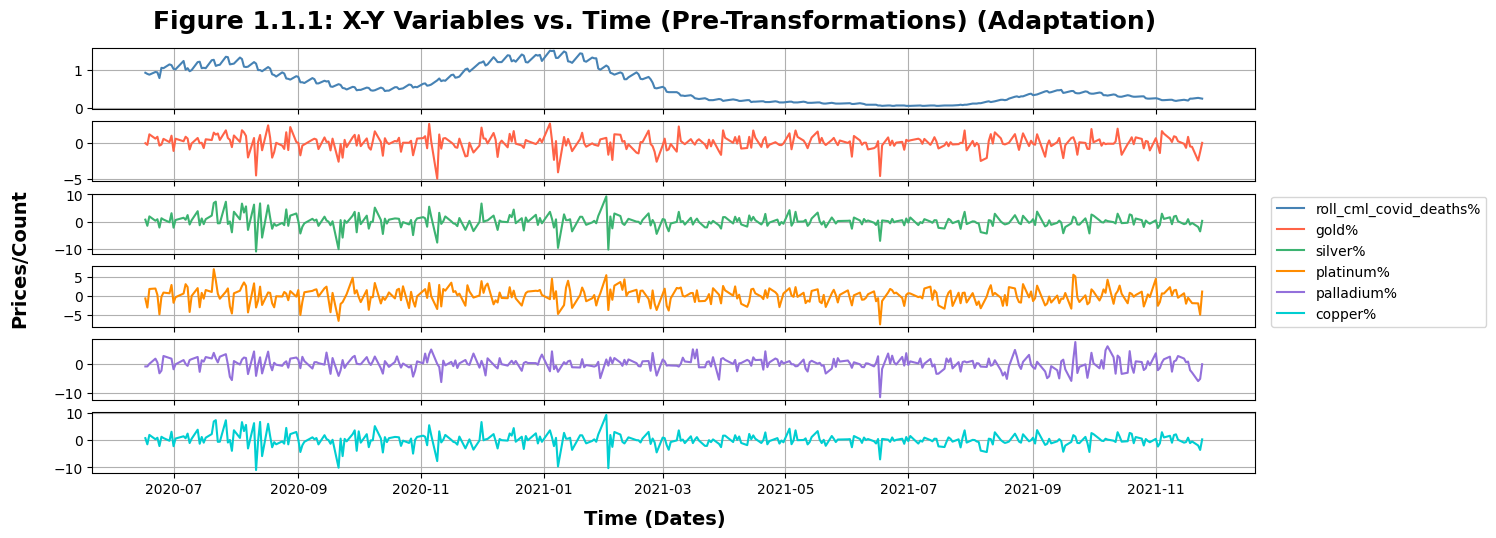

In [16]:
title = f'Figure 1.1.1: X-Y Variables vs. Time (Pre-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.1', PRD, XCAT, YCOL)


matplotlibx.setup_stacked_line_charts(len(ttl_dict))

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(test_df, title)

## **1.1.2: Transformation: X-Y Variables**

### **The Zivot-Andrews Test: X-Y Variables (Pre-Transformations)**

In [17]:
title = 'Table 1.1.2.1: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(ttl_dict, autolag = 'AIC')

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
roll_cml_covid_deaths%,-4.75,0.0605,-5.28,-4.81,-4.57,365,14,171,2021-02-22,46.8%,constant only,AIC,False,ambiguous
gold%,-19.74,0.0009,-5.03,-4.41,-4.14,365,0,55,2020-09-03,15.1%,trend only,AIC,True,stationary with break
silver%,-22.69,0.0009,-5.03,-4.41,-4.14,365,0,67,2020-09-22,18.4%,trend only,AIC,True,stationary with break
platinum%,-18.33,0.0009,-5.03,-4.41,-4.14,365,0,117,2020-12-02,32.1%,trend only,AIC,True,stationary with break
palladium%,-18.44,0.0009,-5.03,-4.41,-4.14,365,0,207,2021-04-14,56.7%,trend only,AIC,True,stationary with break
copper%,-22.69,0.0009,-5.03,-4.41,-4.14,365,0,67,2020-09-22,18.4%,trend only,AIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Pre-Transformations)**

In [18]:
title = 'Table 1.1.2.2: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
roll_cml_covid_deaths%,3,"[50, 110, 175]","[13.7, 30.1, 47.9]",365,l2,mean shift detection (changes in level),pelt
gold%,1,[35],[9.6],365,l2,mean shift detection (changes in level),pelt
silver%,1,[35],[9.6],365,l2,mean shift detection (changes in level),pelt
platinum%,2,"[95, 170]","[26.0, 46.6]",365,l2,mean shift detection (changes in level),pelt
palladium%,2,"[290, 325]","[79.5, 89.0]",365,l2,mean shift detection (changes in level),pelt
copper%,1,[35],[9.6],365,l2,mean shift detection (changes in level),pelt


### **The Augmented Dickey-Fuller (ADF) Test: X-Y Variables (Pre-Transformations)**

In [19]:
title = 'Table 1.1.2.3: The Augmented Dickey-Fuller (ADF) Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.adf_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,adf_stat,p_value,used_lag,n_obs,1%,5%,10%,margin,regr. mthd.,autolag,stationary
series,,,,,,,,,,,
roll_cml_covid_deaths%,-3.65,0.0260,13,351,-3.98,-3.42,-3.13,-0.22,constant and trend,BIC,True
gold%,-19.59,0.0000,0,364,-2.57,-1.94,-1.62,-17.65,"no constant, no trend",BIC,True
silver%,-22.29,0.0000,0,364,-2.57,-1.94,-1.62,-20.35,"no constant, no trend",BIC,True
platinum%,-18.30,0.0000,0,364,-2.57,-1.94,-1.62,-16.36,"no constant, no trend",t-stat,True
palladium%,-18.32,0.0000,0,364,-2.57,-1.94,-1.62,-16.37,"no constant, no trend",t-stat,True
copper%,-22.29,0.0000,0,364,-2.57,-1.94,-1.62,-20.35,"no constant, no trend",BIC,True


### **The Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test: X-Y Variables (Pre-Transformations)** 

In [20]:
title = 'Table 1.1.2.4: The KPSS Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.kpss_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,kpss_stat,p_value,n_lags,n_lags_used,1%,5%,10%,margin,regr. mthd.,stationary
series,,,,,,,,,,
roll_cml_covid_deaths%,0.14,0.0611,legacy,17,0.22,0.15,0.12,-0.01,constant and trend,True
gold%,0.10,0.1000,None,2,0.74,0.46,0.35,-0.37,constant only,True
silver%,0.34,0.1000,legacy,17,0.74,0.46,0.35,-0.12,constant only,True
platinum%,0.20,0.1000,None,5,0.74,0.46,0.35,-0.26,constant only,True
palladium%,0.34,0.1000,None,1,0.74,0.46,0.35,-0.13,constant only,True
copper%,0.34,0.1000,legacy,17,0.74,0.46,0.35,-0.12,constant only,True


### **Cross-Validation for Stationarity - X-Y Variables (Pre-Transformations)** 

In [21]:
title = 'Table 1.1.2.5: The Cross-Validation for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
roll_cml_covid_deaths%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
gold%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
silver%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
platinum%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
palladium%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
copper%,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **Transformations for Stationarity - X-Y Variables**

In [22]:
trns_df = mathx.crct_stnry_df(ttl_dict)

STATIONARY TIME SERIES DETECTED: roll_cml_covid_deaths%.


STATIONARY TIME SERIES DETECTED: gold%.


STATIONARY TIME SERIES DETECTED: silver%.


STATIONARY TIME SERIES DETECTED: platinum%.


STATIONARY TIME SERIES DETECTED: palladium%.


STATIONARY TIME SERIES DETECTED: copper%.




### **Cross-Validation for Stationarity - X-Y Variables (Post-Transformations)** 

In [23]:
title = 'Table 1.1.2.6: Corrections for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
roll_cml_covid_deaths%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
gold%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
silver%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
platinum%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
palladium%,True,True,stationary,Both tests agree the series is stationary.,No action needed.
copper%,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **The Zivot-Andrews Test: X-Y Variables (Post-Transformations)**

In [24]:
title = 'Table 1.1.2.7: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
roll_cml_covid_deaths%,-5.11,0.0201,-5.28,-4.81,-4.57,365,13,171,2021-02-22,46.8%,constant only,BIC,True,stationary with break
gold%,-19.74,0.0009,-5.03,-4.41,-4.14,365,0,55,2020-09-03,15.1%,trend only,BIC,True,stationary with break
silver%,-22.69,0.0009,-5.03,-4.41,-4.14,365,0,67,2020-09-22,18.4%,trend only,BIC,True,stationary with break
platinum%,-18.33,0.0009,-5.03,-4.41,-4.14,365,0,117,2020-12-02,32.1%,trend only,BIC,True,stationary with break
palladium%,-18.44,0.0009,-5.03,-4.41,-4.14,365,0,207,2021-04-14,56.7%,trend only,BIC,True,stationary with break
copper%,-22.69,0.0009,-5.03,-4.41,-4.14,365,0,67,2020-09-22,18.4%,trend only,BIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Post-Transformations)**

In [25]:
title = 'Table 1.1.2.8: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
roll_cml_covid_deaths%,3,"[50, 110, 175]","[13.7, 30.1, 47.9]",365,l2,mean shift detection (changes in level),pelt
gold%,1,[35],[9.6],365,l2,mean shift detection (changes in level),pelt
silver%,1,[35],[9.6],365,l2,mean shift detection (changes in level),pelt
platinum%,2,"[95, 170]","[26.0, 46.6]",365,l2,mean shift detection (changes in level),pelt
palladium%,2,"[290, 325]","[79.5, 89.0]",365,l2,mean shift detection (changes in level),pelt
copper%,1,[35],[9.6],365,l2,mean shift detection (changes in level),pelt


### **Display X-Y Variables (Post-Transformations)**

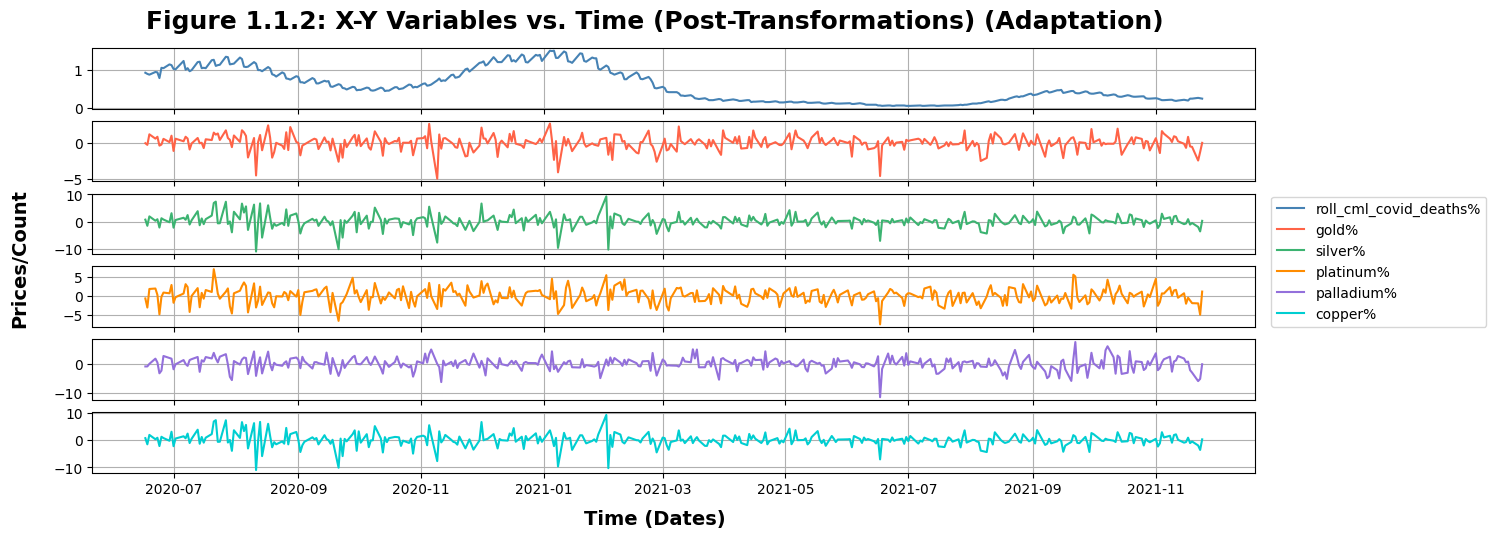

In [26]:
title = f'Figure 1.1.2: X-Y Variables vs. Time (Post-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.2', PRD, XCAT, YCOL)
        

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(trns_df, title)

### **Assign Data to Series - X-Y Variables (Post-Transformations)**

In [27]:
if YPCT:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value] + '%']

    y2_series = trns_df[YCAT[Y.Y2.value] + '%']

    y3_series = trns_df[YCAT[Y.Y3.value] + '%']

    y4_series = trns_df[YCAT[Y.Y4.value] + '%']

    y5_series = trns_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value]]

    y2_series = trns_df[YCAT[Y.Y2.value]]

    y3_series = trns_df[YCAT[Y.Y3.value]]

    y4_series = trns_df[YCAT[Y.Y4.value]]

    y5_series = trns_df[YCAT[Y.Y5.value]]

---

## Interpretation: Section 1.1.2 — Stationarity Analysis and Transformations

**Why This Section Matters More Carefully Here.** Because both X and Y are already in percentage-change form, the stationarity picture is fundamentally cleaner than in a levels analysis. Percentage changes of integrated price and count series are theoretically I(0), so the primary purpose of Section 1.1.2 is to confirm that this holds empirically and to identify any residual non-stationarity introduced by the specific structure of the `covid_deaths` series during the Adaptation period.

**Pre-Transformation Stationarity Tests.** The ADF test (Table 1.1.2.3) should reject the null of a unit root for most or all series, and the KPSS test (Table 1.1.2.4) should fail to reject stationarity. Where these results conflict — particularly for the `covid_deaths` pct-change series — the issue is likely driven by the intermittent spike-and-flat structure of the death-rate percentage changes rather than true non-stationarity. Long stretches where cumulative deaths grew smoothly (making the percentage change near-constant) can mimic persistence and cause the ADF test to understate the evidence for stationarity. The cross-validation table (Table 1.1.2.5) synthesizes all four test results into a consensus stationarity classification per series.

**Structural Breaks.** The Zivot-Andrews test (Table 1.1.2.1) and Bai-Perron test (Table 1.1.2.2) applied to the percentage-change series test for breaks in the level or trend of the return/change process. For the `covid_deaths` pct-change series, Bai-Perron is likely to detect a break at the onset of the Delta wave (approximately July–August 2021), where the death-rate percentage changes spiked after a prolonged quiet period. For metal returns, breaks may coincide with commodity cycle turning points: the initial rally of Q4 2020, the peak of the industrial metals rally in May–June 2021, and the partial correction that followed. Knowing where these breaks fall helps contextualize any instability in the rolling correlations analyzed in Sections 1.1.3–1.1.7.

**Post-Transformation Confirmation.** Tables 1.1.2.6–1.1.2.8 and Figure 1.1.2 confirm the stationarity state after any additional corrections applied by `mathx.crct_stnry_df()`. For well-behaved percentage-change series, the pre- and post-transformation plots (Figures 1.1.1 and 1.1.2) should look similar, with only minor adjustments. If any series required second differencing — an unusual outcome for a pct-change series — that would signal a structural peculiarity worth flagging in the interpretation of downstream Granger and VECM results for that metal.

---


## **1.1.3: X vs. Y1**

### **Create DataFrame X vs. Y1**

In [28]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y1.value]: y1_series})

logx.log_write_obj(comp_df)

In [29]:
title = f'Table 1.1.3.1: {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y1.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_deaths%,gold
series,,
2020-06-17,1,-0
2020-06-18,1,-0
2020-06-19,1,1
2020-06-22,1,1
2020-06-23,1,1
2020-06-24,1,-0
2020-06-25,1,-0
2020-06-26,1,1
2020-06-29,1,0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y1**

In [30]:
title = 'Table 1.1.3.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y1_series, x_series)

corr_method = mathx.find_opt_corr_method(y1_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-52.69,95.38,0.81,-623.24,0.33,True,0.57
2,0.02,-51.68,93.66,0.99,-628.72,1.00,True,1.00
3,0.03,-51.70,93.61,0.99,-628.11,0.93,True,0.96
4,0.03,-51.65,93.28,1.00,-627.01,0.79,True,0.90
5,0.03,-52.66,95.28,0.82,-625.49,0.61,True,0.71
6,0.03,-52.56,95.02,0.83,-623.99,0.42,True,0.63
7,0.03,-53.90,93.86,0.59,-623.37,0.35,True,0.47
8,0.04,-54.45,93.50,0.49,-622.26,0.21,True,0.35
9,0.04,-57.14,93.88,0.00,-621.44,0.11,True,0.06
10,0.04,-55.08,93.94,0.38,-620.51,0.00,True,0.19


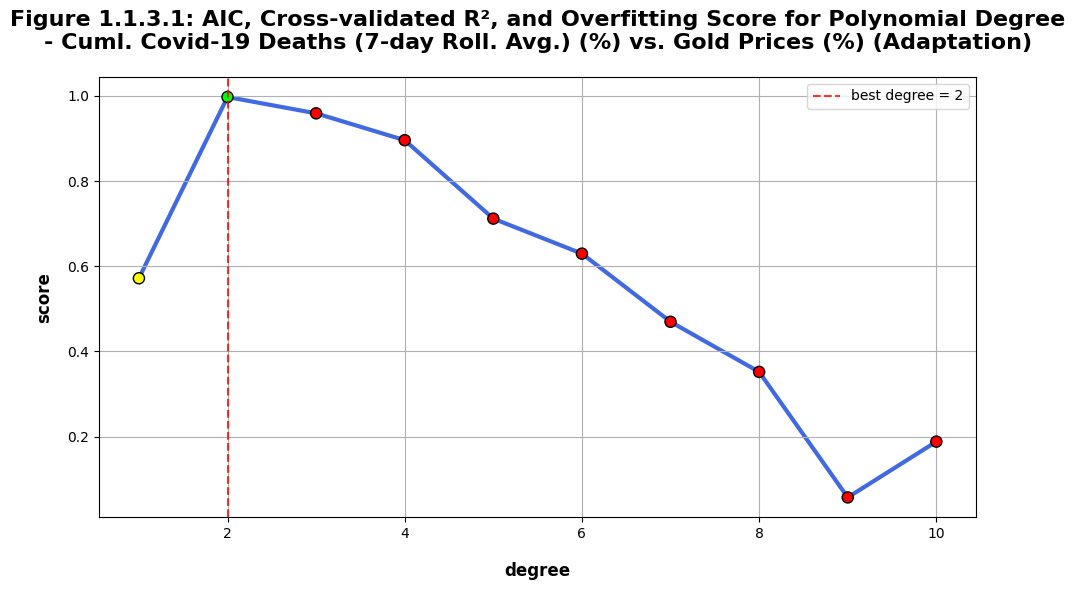

In [31]:
title = 'Figure 1.1.3.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y1**

In [32]:
title = f'Table 1.1.3.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_deaths%,gold
roll_cml_covid_deaths%,1.00,0.05
gold,0.05,1.00


### **Scatter Plot: X vs. Y1**

r-value (pearson):	0.036
r-value (spearman):	0.054
tau (kendall):		0.031

p-value (pearson):	0.498
p-value (spearman):	0.305
p-value (kendall):	0.375




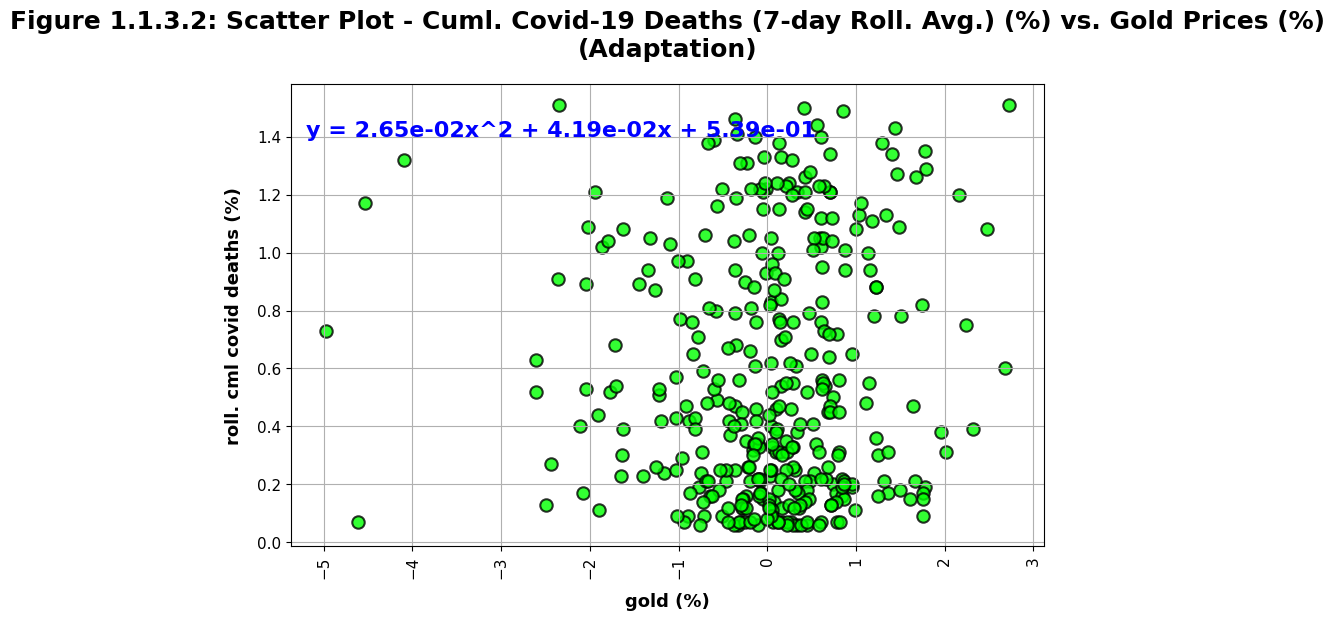

In [33]:
title = 'Figure 1.1.3.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.3.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y1.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y1_series, x_series], title)

### **The Granger Causality Test: X -> Y1**

In [34]:
title = 'Table 1.1.3.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y1_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y1_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y1_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list = [best_dict]

grngr_nm_list  = [f'{XCAT} -> {YCAT[Y.Y1.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.217878,0.640943,False,False,False,False,high confidence
2,0.872880,0.418634,False,False,False,False,high confidence
3,0.675770,0.567361,False,False,False,False,high confidence
4,0.511468,0.727347,False,False,False,False,high confidence
5,0.423758,0.832099,False,False,False,False,high confidence
6,1.797778,0.098680,False,False,False,False,high confidence
7,1.565760,0.144522,False,False,False,False,high confidence
8,1.326247,0.229180,False,False,False,False,high confidence


### **The Granger Causality Test: Y1 -> X**

In [35]:
title = 'Table 1.1.3.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y1.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y1_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y1.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.085938,0.769574,False,False,False,False,high confidence
2,0.269592,0.763846,False,False,False,False,high confidence
3,0.219202,0.883054,False,False,False,False,high confidence
4,0.287040,0.886334,False,False,False,False,high confidence
5,1.143553,0.336960,False,False,False,False,high confidence
6,0.537879,0.779366,False,False,False,False,high confidence
7,0.612578,0.745547,False,False,False,False,high confidence
8,0.623866,0.757768,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y1**

In [36]:
results_dict = mathx.fit_var_or_vecm(x_series, y1_series)

x_y1_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_DEATHS% VS. GOLD% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.571232, p = 0.099090).

Series 'y' is stationary (ADF = -19.571625, p = 0.000000).

Trace and max-eigenvalue tests agree. One cointegrating relationship detected — VECM is appropriate.

Recommended lag (BIC): 8.
AIC = 15, BIC = 8, HQIC = 8, FPE = 15.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: 0.000100, y: 0.034628. Error correction half-life: inf periods. x - (34.845737) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 5 (magnitude: 2.279831).
Cumulative x→y response: 8.958982.

FEVD (VECM, horizon = 31):
x shocks explain 2.125822% of y's forecast variance (minimal influence).
y's own shocks explain 97.874178% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y1**

In [37]:
title = 'Table 1.1.3.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    irf_bool = True

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.694626,1.857173,-0.002181,-0.043005
2,0.786454,0.455581,-0.001064,-0.019361
3,0.735062,0.987863,-0.003499,-0.009848
4,0.901399,0.337141,-0.002184,-0.124956
5,1.372538,2.279831,0.000254,-0.036949
6,1.376984,-0.612967,-0.002144,-0.043937
7,0.983452,0.539020,-0.002950,0.016255
8,1.215589,-0.218940,-0.003719,0.087616


### **Forecast Error Variance Decomposition (FEVD): X vs. Y1**

In [38]:
if irf_bool:
    
    title = 'Table 1.1.3.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

else:

    title = 'Table 1.1.3.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'    

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.000780,0.999220,1.000000,0.000000
1,0.005791,0.994209,0.997908,0.002092
2,0.006058,0.993942,0.998179,0.001821
3,0.007446,0.992554,0.995503,0.004497
4,0.007408,0.992592,0.995678,0.004322
5,0.014592,0.985408,0.997172,0.002828
6,0.015233,0.984767,0.997547,0.002453
7,0.015624,0.984376,0.997221,0.002779
8,0.015557,0.984443,0.996812,0.003188


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y1**

In [39]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y1_series, method = corr_method)

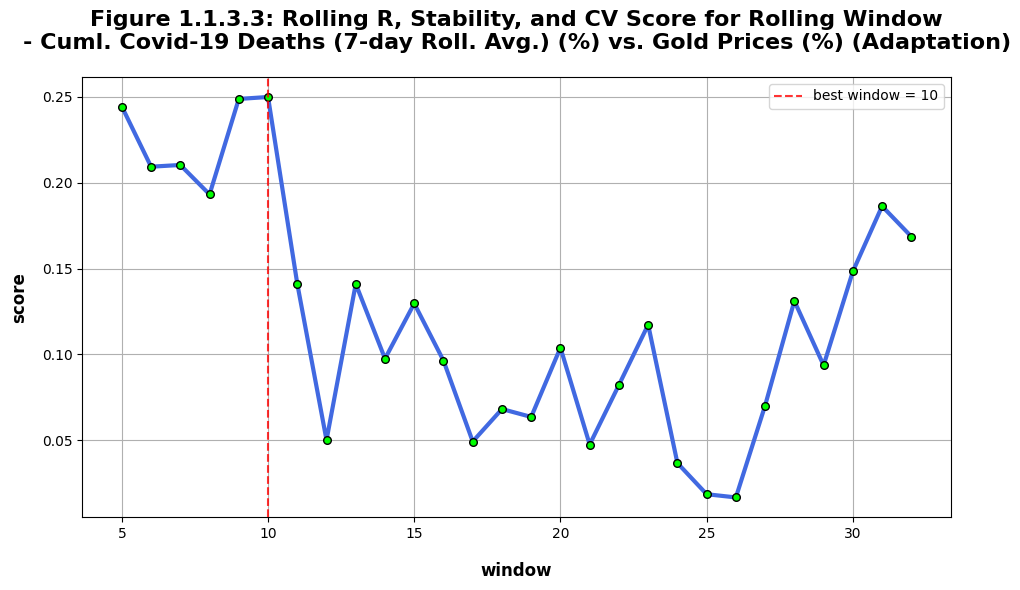

In [40]:
title = 'Figure 1.1.3.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y1**

In [41]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y1_series, best_w, method = corr_method)

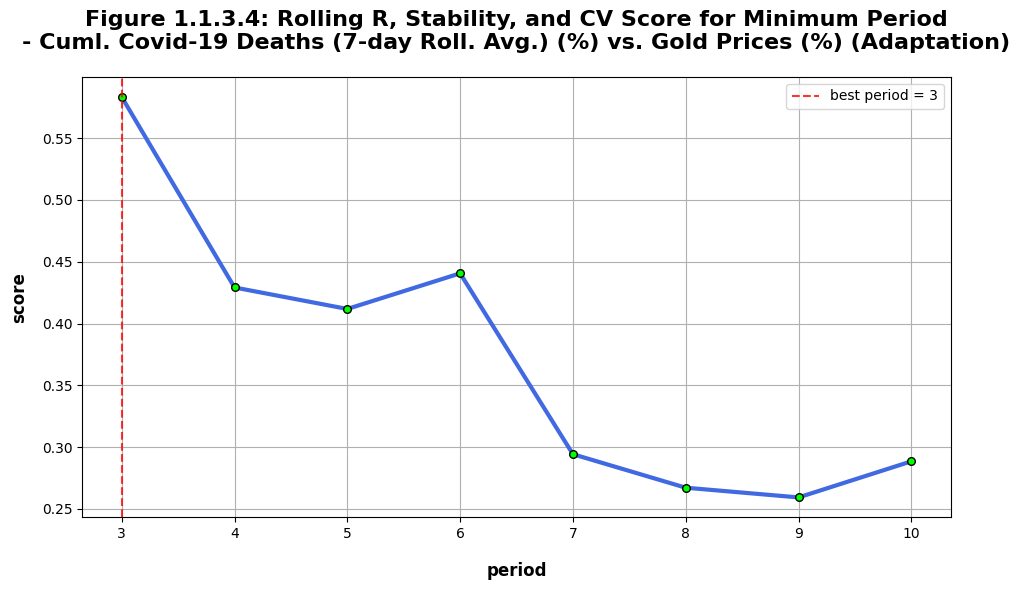

In [42]:
title = 'Figure 1.1.3.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y1**

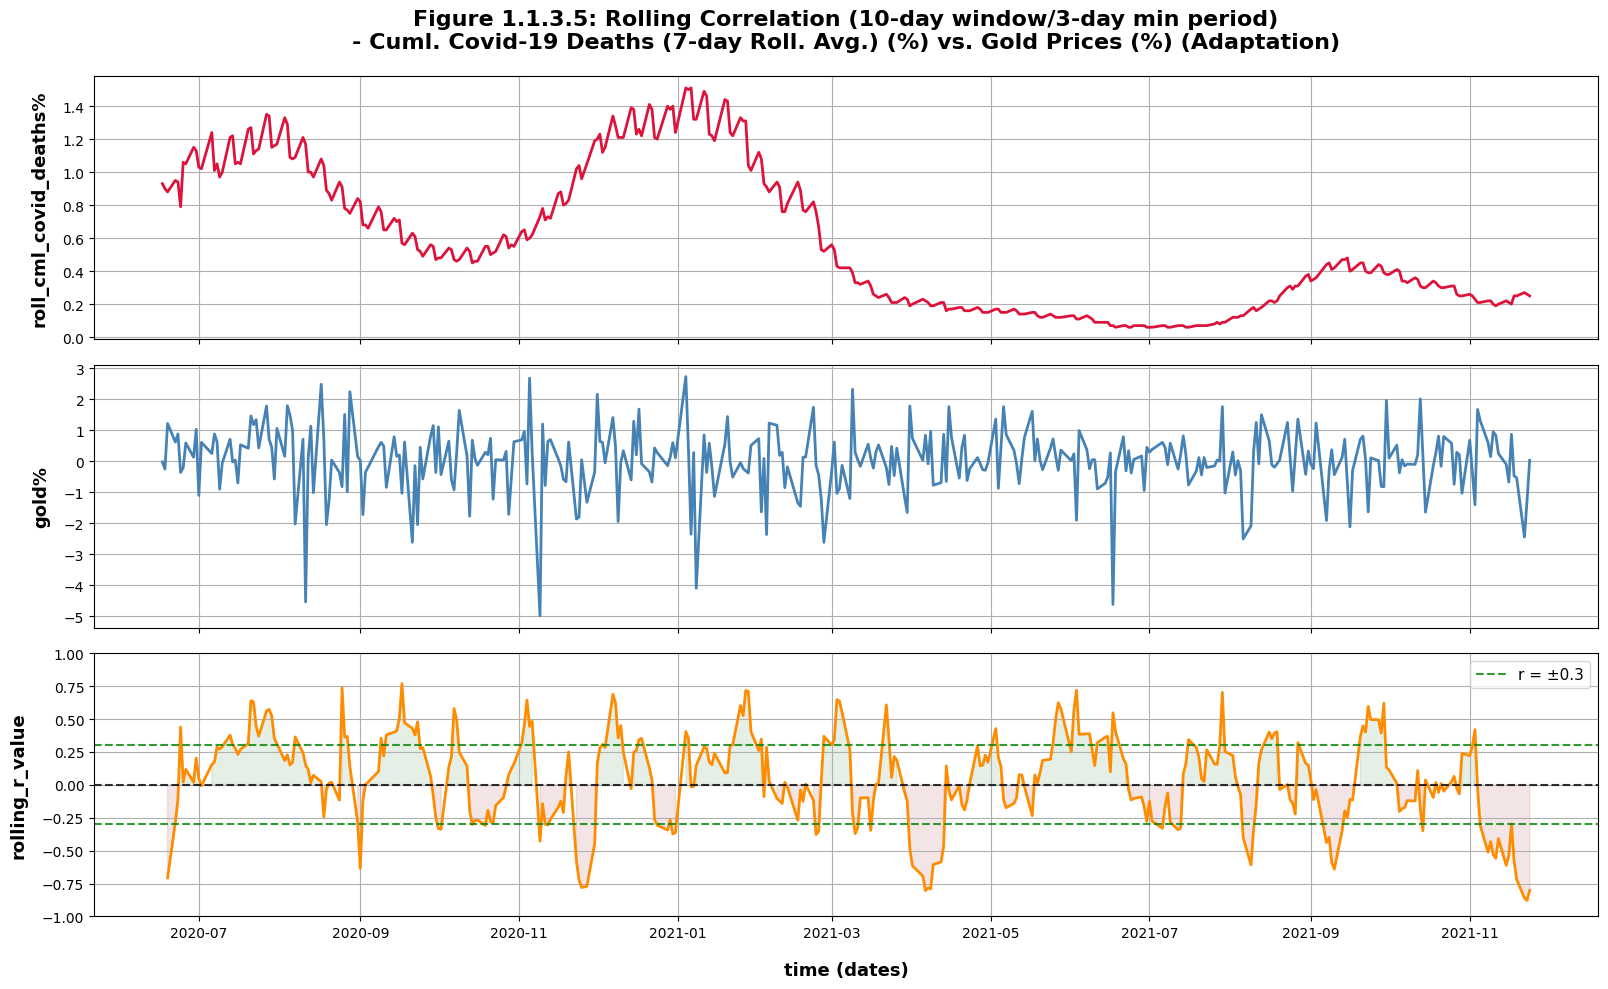

In [43]:
title \
    = f'Figure 1.1.3.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_roll_corr_xylabels('time (dates)', [])

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)


matplotlibx.plot_rolling_corr_lines(x_series, y1_series, title)

### **Lag Correlation: X vs. Y1**

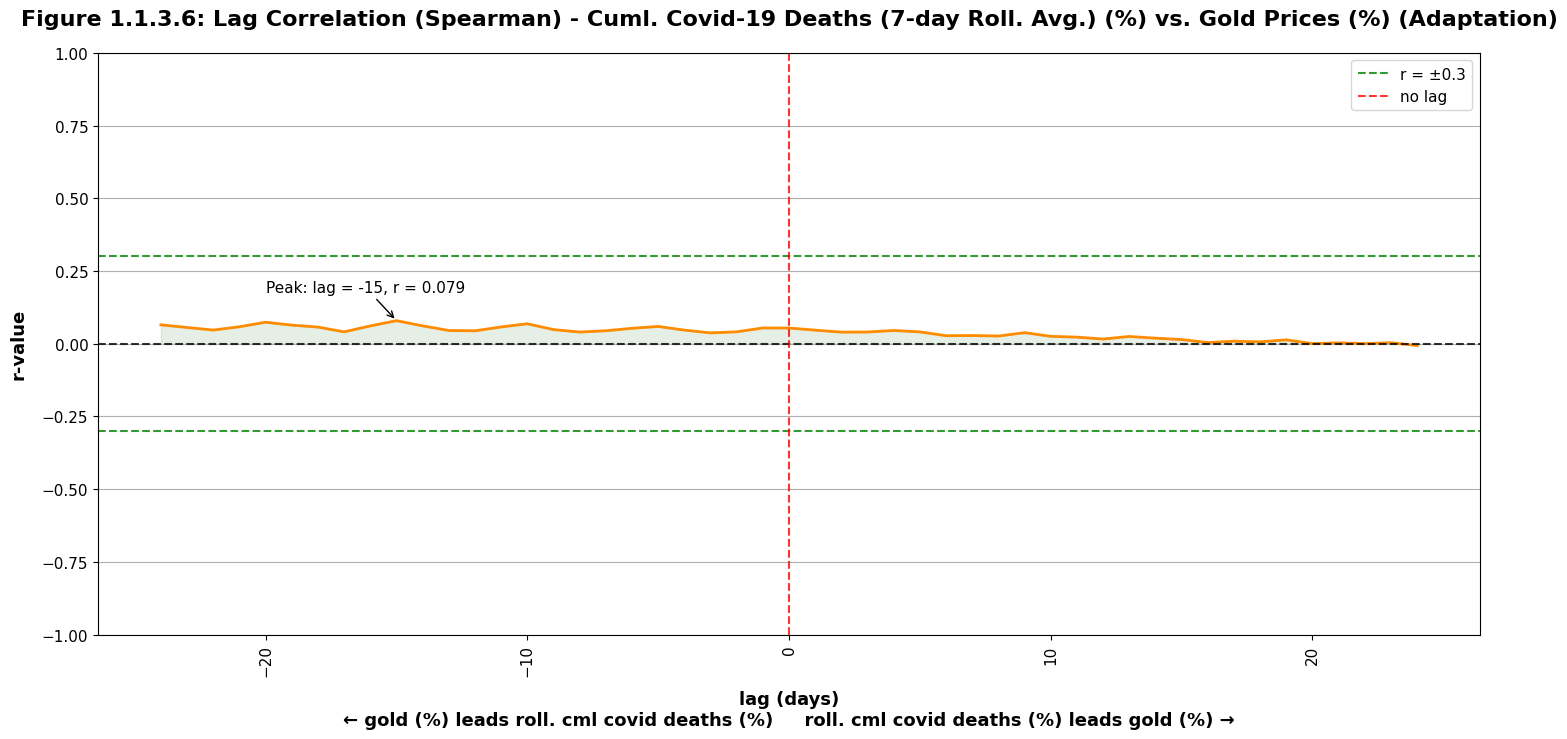

In [44]:
title = f'Figure 1.1.3.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.3.6', PRD, XCAT, YCOL)


v_lag       = int(x_y1_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y1_series, v_lag, g_lag)

max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y1.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y1_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.3 — `covid_deaths` (%) vs. Y1 Metal Return (%)

**Correlation and Functional Form.** Operating in percentage-change form, the contemporaneous correlation between COVID death-rate changes and Y1 metal returns measures whether the two series move together in the same direction on the same day after accounting for their respective levels histories. During the Adaptation period, contemporaneous correlations across most commodity-pandemic pairs are expected to be weak: markets had largely normalized to background pandemic risk by mid-2020, and same-day co-movement between death-rate news and metal prices would require a very tight informational link. A polynomial degree above 1 for this pair would suggest a nonlinear return response — for example, metal prices reacting disproportionately only when death-rate percentage changes exceeded a threshold (reflecting a fear-threshold mechanism during wave resurgences).

**Granger Causality.** The Granger tests for Y1 (Tables 1.1.3.4 and 1.1.3.5) determine whether past percentage changes in COVID deaths help predict Y1's returns beyond Y1's own lagged returns. In percentage-change form on stationary series, the Granger test is more cleanly interpreted than in levels: a significant F-statistic in the X→Y1 direction genuinely reflects predictive information content, not shared trend momentum. The reverse direction (Y1→X) tests whether metal returns anticipated death-rate changes — a finding that would be difficult to interpret causally and most likely reflects a coincidental lag structure rather than markets predicting epidemiological outcomes.

**VAR/VECM Dynamics.** Because both series are in percentage-change form and expected to be stationary, the model selected by `mathx.fit_var_or_vecm()` is more likely to be a VAR in differences than a VECM, since cointegration requires both series to be I(1) in levels — not satisfied here. The IRF for Y1 quantifies how many days a shock to COVID death-rate changes persists in metal returns, and the FEVD X-share in Y1 captures what fraction of Y1's return variance is attributable to the death-rate shock at each forecast horizon. Even a modest FEVD X-share (5–15%) would be economically meaningful during the Adaptation period, given the many competing drivers of metal prices in this window.

**Rolling and Lag Correlations.** The rolling correlation for Y1 (Figure 1.1.3.5) will reveal whether the COVID death rate–metal return relationship was relatively stable across the 536-day window or concentrated in specific sub-episodes. The Delta wave of July–September 2021 is the most likely candidate for a sub-episode where the rolling correlation strengthened, as rising deaths during that wave briefly re-engaged pandemic risk channels. A positive peak lag in the lag correlation (Figure 1.1.3.6) — COVID death changes preceding Y1 returns by several days — would confirm a leading rather than contemporaneous informational relationship.

---


## **1.1.4: X vs. Y2**

### **Create DataFrame X vs. Y2**

In [45]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y2.value]: y2_series})

logx.log_write_obj(comp_df)

In [46]:
title = f'Table 1.1.4.1: {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y2.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_deaths%,silver
series,,
2020-06-17,1,1
2020-06-18,1,-2
2020-06-19,1,2
2020-06-22,1,0
2020-06-23,1,1
2020-06-24,1,-2
2020-06-25,1,1
2020-06-26,1,1
2020-06-29,1,-0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y2**

In [47]:
title = 'Table 1.1.4.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y2_series, x_series)

corr_method = mathx.find_opt_corr_method(y2_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.01,-51.84,93.82,0.13,-628.25,0.00,True,0.06
2,0.09,-47.14,85.99,0.87,-653.38,1.00,True,0.93
3,0.09,-47.18,85.97,0.86,-651.40,0.92,True,0.89
4,0.09,-47.02,85.65,0.89,-650.01,0.87,True,0.88
5,0.09,-46.86,85.39,0.91,-648.81,0.82,True,0.87
6,0.09,-47.07,85.46,0.88,-646.93,0.74,True,0.81
7,0.09,-47.45,85.63,0.82,-644.99,0.67,True,0.74
8,0.10,-47.04,84.19,0.88,-645.99,0.71,True,0.80
9,0.10,-52.66,81.80,0.00,-644.06,0.63,True,0.31
10,0.10,-46.31,83.52,1.00,-644.43,0.64,True,0.82


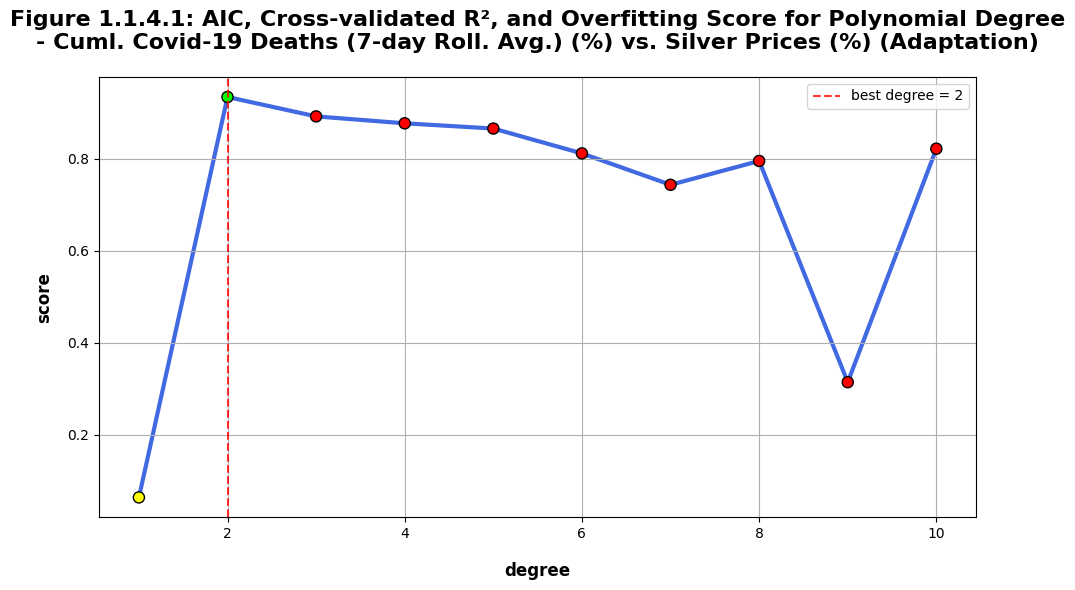

In [48]:
title = 'Figure 1.1.4.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y2**

In [49]:
title = f'Table 1.1.4.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_deaths%,silver
roll_cml_covid_deaths%,1.00,0.12
silver,0.12,1.00


### **Scatter Plot: X vs. Y2**

r-value (pearson):	0.122
r-value (spearman):	0.124
tau (kendall):		0.080

p-value (pearson):	0.020
p-value (spearman):	0.018
p-value (kendall):	0.023




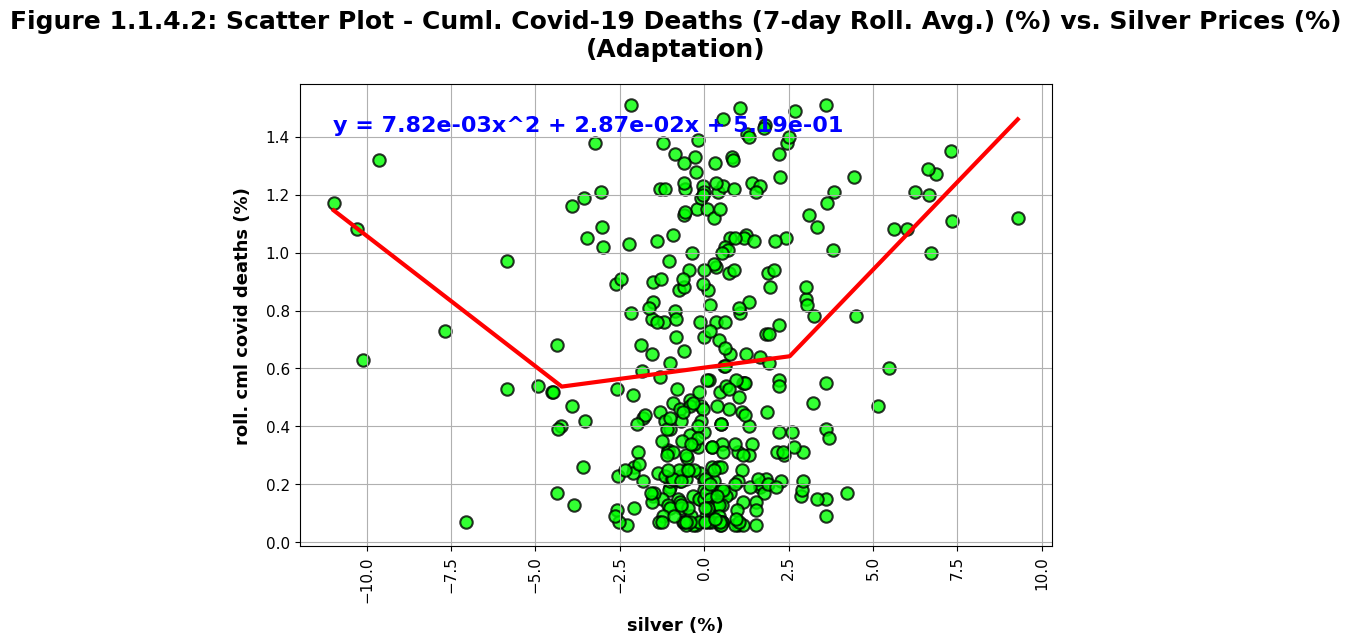

In [50]:
title = 'Figure 1.1.4.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.4.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y2.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y2_series, x_series], title)

### **The Granger Causality Test: X -> Y2**

In [51]:
title = 'Table 1.1.4.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y2_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y2_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y2_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y2.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,5.279499,0.022149,True,True,True,True,high confidence


### **The Granger Causality Test: Y2 -> X**

In [52]:
title = 'Table 1.1.4.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y2.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y2_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y2.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.698212,0.403938,False,False,False,False,high confidence
2,1.642124,0.195023,False,False,False,False,high confidence
3,0.505549,0.678687,False,False,False,False,high confidence
4,0.239926,0.915634,False,False,False,False,high confidence
5,0.591573,0.706456,False,False,False,False,high confidence
6,0.345349,0.912404,False,False,False,False,high confidence
7,0.833823,0.559771,False,False,False,False,high confidence
8,0.608800,0.770495,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y2**

In [53]:
results_dict = mathx.fit_var_or_vecm(x_series, y2_series)

x_y2_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_DEATHS% VS. SILVER% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.571232, p = 0.099090).

Series 'y' is stationary (ADF = -22.314382, p = 0.000000).

Trace and max-eigenvalue tests agree. One cointegrating relationship detected — VECM is appropriate.

Recommended lag (BIC): 8.
AIC = 16, BIC = 8, HQIC = 13, FPE = 16.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: 0.000917, y: 0.428049. Error correction half-life: inf periods. x - (3.039357) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 5 (magnitude: 6.752147).
Cumulative x→y response: 23.056212.

FEVD (VECM, horizon = 31):
x shocks explain 3.244149% of y's forecast variance (minimal influence).
y's own shocks explain 96.755851% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y2**

In [54]:
title = 'Table 1.1.4.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.696849,0.931044,-0.001100,-0.163287
2,0.788221,0.884906,-0.001122,0.024642
3,0.736931,0.994326,-0.001607,-0.026969
4,0.902604,-0.502355,-0.000915,-0.077719
5,1.373297,6.752147,-0.000595,-0.006807
6,1.378073,-2.147159,-0.001871,-0.032723
7,0.987797,1.596527,-0.003126,0.015199
8,1.216069,0.030916,-0.002182,0.028298


### **Forecast Error Variance Decomposition (FEVD): X vs. Y2**

In [55]:
if irf_bool:
    
    title = 'Table 1.1.4.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

else:

    title = 'Table 1.1.4.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}') 

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.005286,0.994714,1.000000,0.000000
1,0.005211,0.994789,0.997422,0.002578
2,0.005530,0.994470,0.996444,0.003556
3,0.005731,0.994269,0.994322,0.005678
4,0.005891,0.994109,0.995134,0.004866
5,0.017749,0.982251,0.996774,0.003226
6,0.019116,0.980884,0.996467,0.003533
7,0.019867,0.980133,0.993668,0.006332
8,0.019881,0.980119,0.993552,0.006448


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y2**

In [56]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y2_series, method = corr_method)

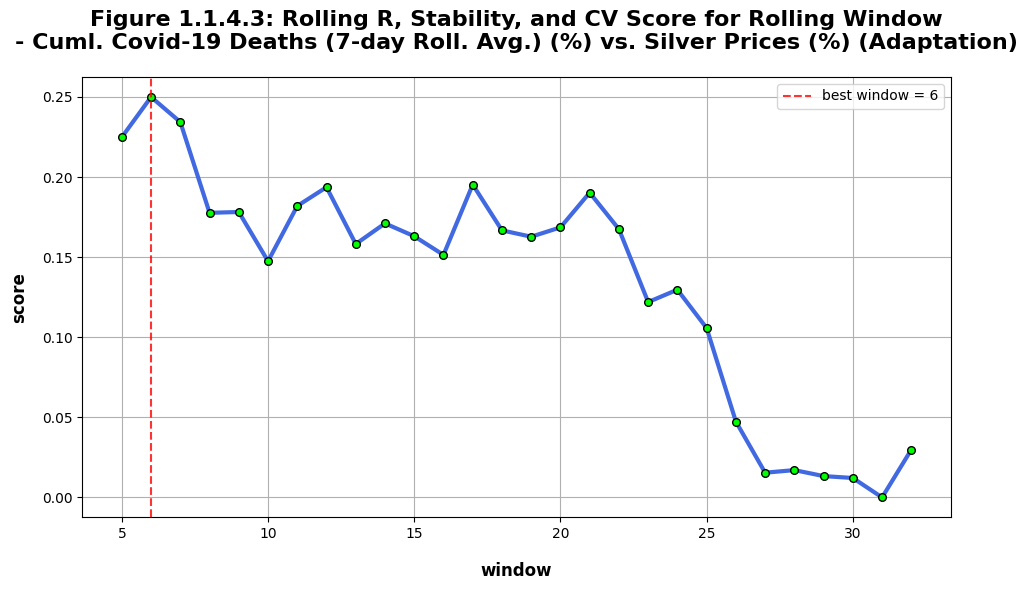

In [57]:
title = 'Figure 1.1.4.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y2**

In [58]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y2_series, best_w, method = corr_method)

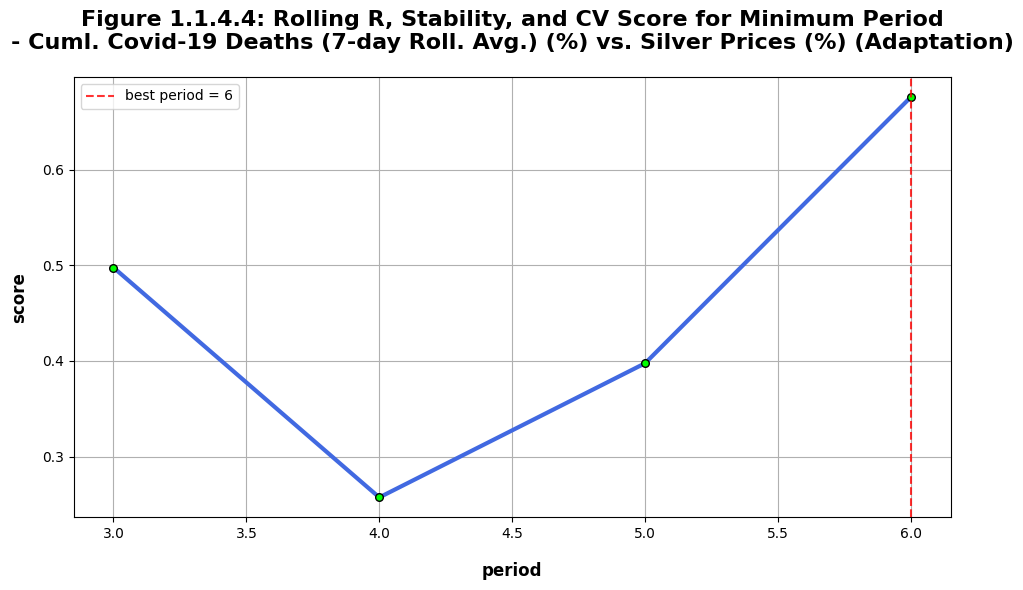

In [59]:
title = 'Figure 1.1.4.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y2**

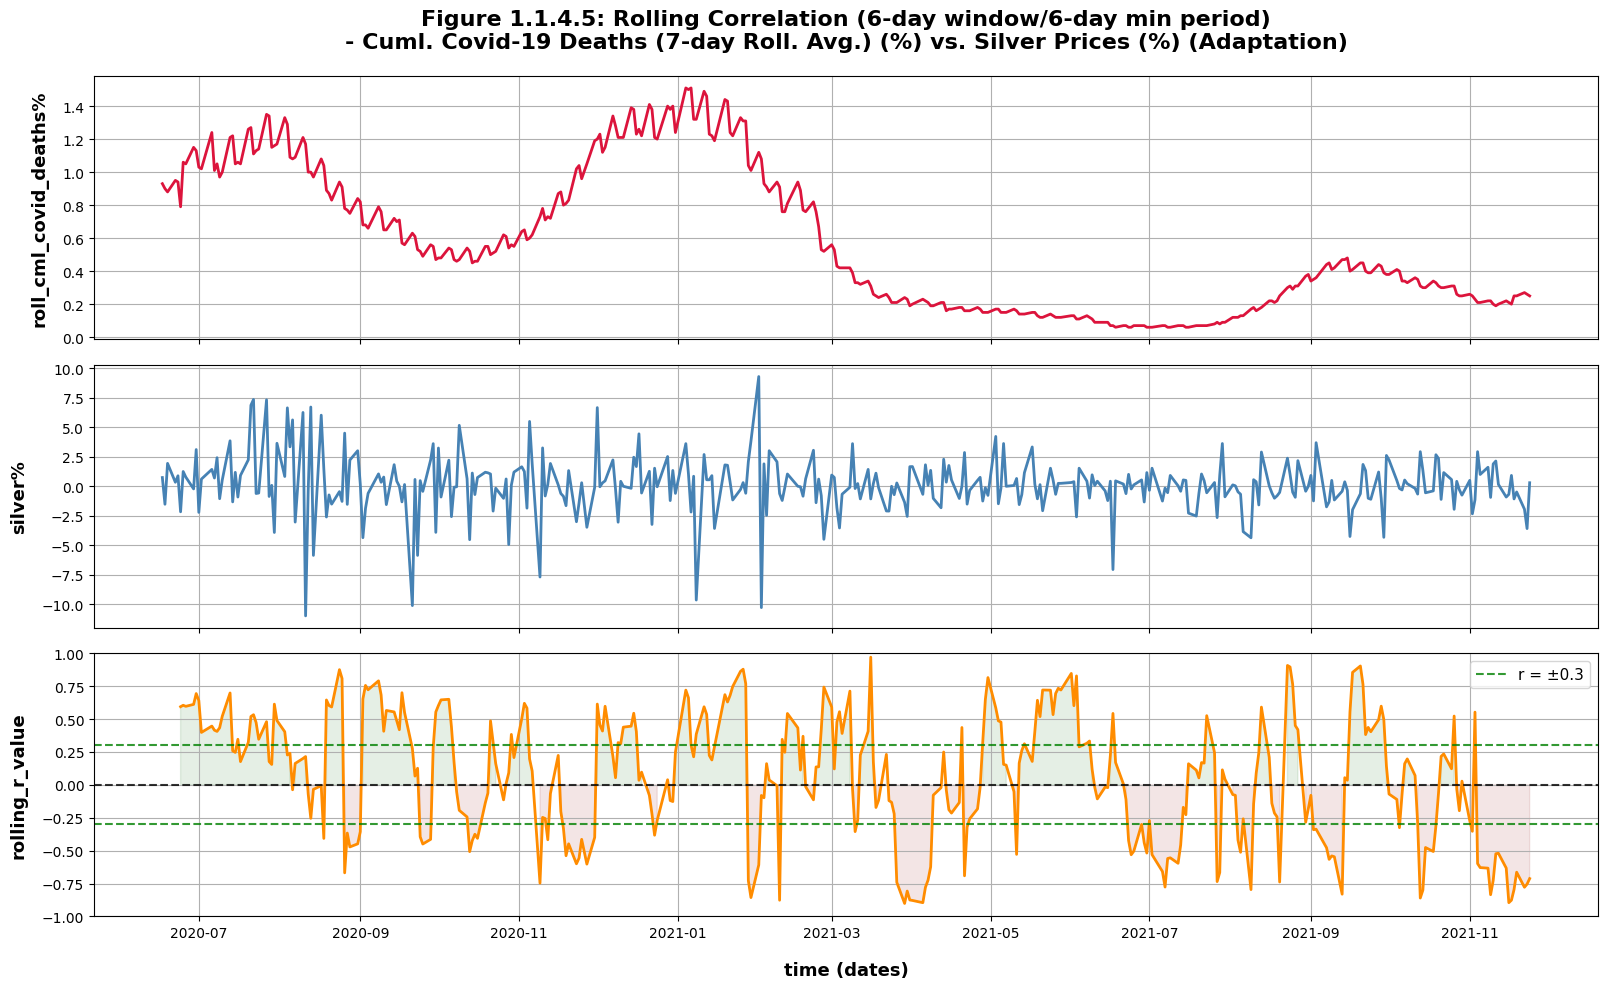

In [60]:
title \
    = f'Figure 1.1.4.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y2_series, title)

### **Lag Correlation: X vs. Y2**

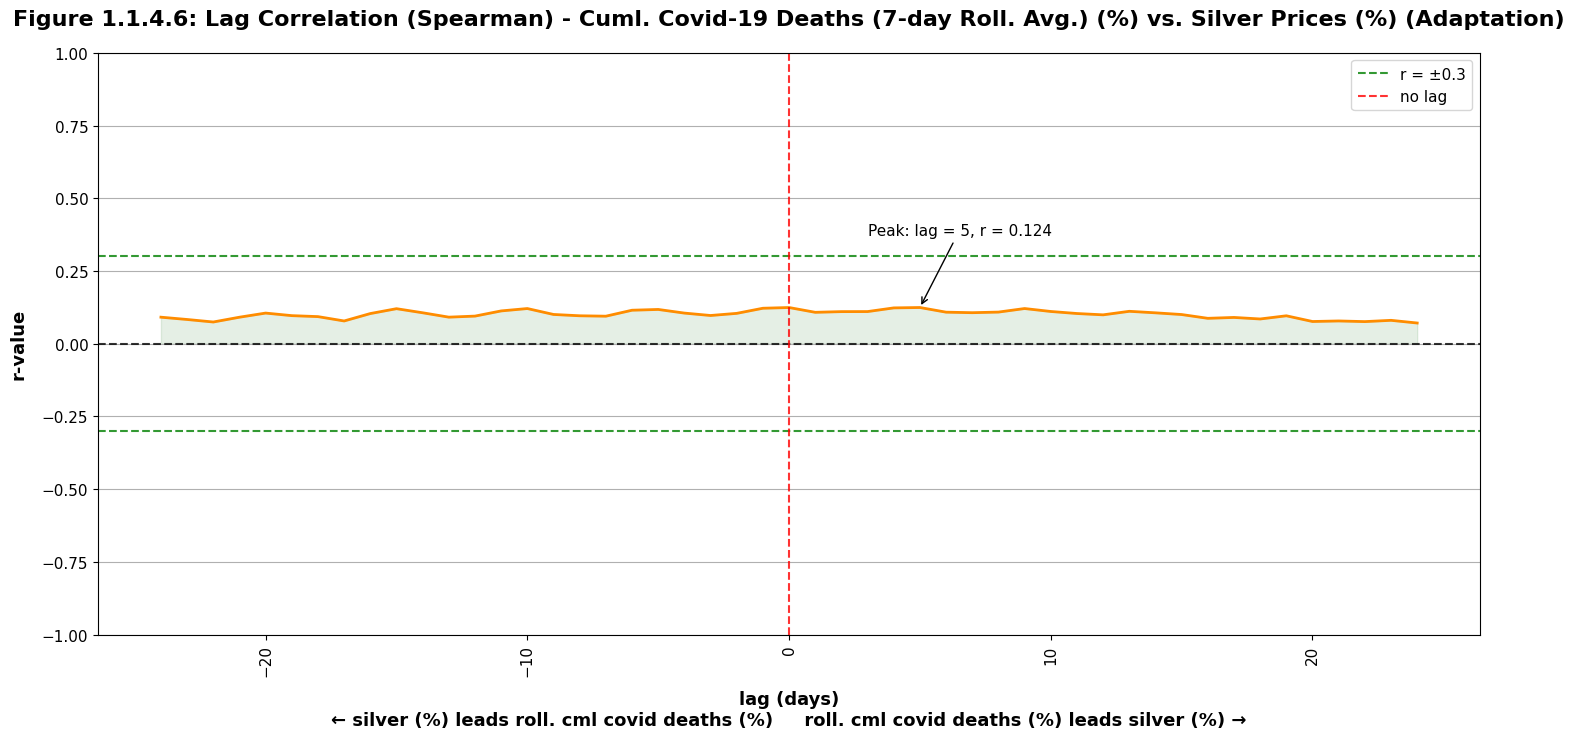

In [61]:
title = f'Figure 1.1.4.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.4.6', PRD, XCAT, YCOL)


v_lag       = int(x_y2_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y2_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y2.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y2_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.4 — `covid_deaths` (%) vs. Y2 Metal Return (%)

**Correlation and Functional Form.** Y2's polynomial degree and correlation results provide the first cross-metal comparison. If Y1 and Y2 have very different optimal degrees or correlation signs, it immediately signals that different metals responded to COVID death-rate changes through different economic channels during the Adaptation period. A positive correlation for one and negative for another would be consistent with the theoretical ambiguity described in the overview — precious metals responding through a safe-haven channel while industrial metals responded through a supply-disruption or demand-growth channel, producing opposite signs under the same COVID shock.

**Granger Causality.** The relative strength of Granger causality for Y2 versus Y1 begins to establish whether the COVID death-rate → metals channel was metal-specific or broad-based. If X→Y2 is significant while X→Y1 was not, it suggests that this particular metal's supply or demand characteristics made it more sensitive to pandemic severity signals during the Adaptation period. Conversely, if both are non-significant, it points to a general decoupling of metal returns from the COVID death-rate signal by this phase of the pandemic.

**VAR/VECM Dynamics.** The IRF and FEVD for Y2 directly complement Y1's results. If Y2's FEVD X-share is materially higher than Y1's, it means death-rate fluctuations explained a larger fraction of this metal's return variance — consistent with greater supply-side vulnerability or greater investor use of this metal as a pandemic sentiment proxy. The IRF peak lag for Y2 versus Y1 reveals whether the two metals incorporated the death-rate signal at different speeds: a longer IRF decay for Y2 would indicate a more persistent, potentially structural response to pandemic severity rather than a transient sentiment shock.

**Rolling and Lag Correlations.** The rolling window selected for Y2 may differ from Y1 if the two metals have different autocorrelation structures in their return series. A shorter optimal window would indicate that the death-rate/Y2 relationship was more locally concentrated — active in brief episodes and then dissolving — while a longer window would suggest a more persistent though perhaps weak association. The lag correlation heatmap in Section 1.1.8 will eventually consolidate the peak lag patterns across all five metals, but Y2's individual lag plot (Figure 1.1.4.6) provides the first detailed look at whether the death-rate leads or lags this metal's returns.

---


## **1.1.5: X vs. Y3**

### **Create DataFrame X vs. Y3**

In [62]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y3.value]: y3_series})

logx.log_write_obj(comp_df)

In [63]:
title = f'Table 1.1.5.1: {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y3.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_deaths%,platinum
series,,
2020-06-17,1,-1
2020-06-18,1,-3
2020-06-19,1,2
2020-06-22,1,2
2020-06-23,1,0
2020-06-24,1,-5
2020-06-25,1,-0
2020-06-26,1,1
2020-06-29,1,1


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y3**

In [64]:
title = 'Table 1.1.5.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y3_series, x_series)

corr_method = mathx.find_opt_corr_method(y3_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.01,-51.83,93.75,0.98,-627.33,0.00,True,0.49
2,0.03,-50.28,90.47,0.99,-633.48,0.78,True,0.89
3,0.04,-51.07,91.64,0.98,-631.82,0.57,True,0.78
4,0.05,-50.24,89.84,0.99,-634.01,0.85,True,0.92
5,0.05,-48.84,87.44,1.00,-635.20,1.00,True,1.00
6,0.05,-49.47,87.07,1.00,-633.20,0.75,True,0.87
7,0.06,-50.19,88.45,0.99,-631.81,0.57,True,0.78
8,0.06,-82.33,151.97,0.76,-631.57,0.54,True,0.65
9,0.06,-187.05,363.15,0.00,-629.65,0.29,True,0.15
10,0.06,-149.46,195.94,0.27,-628.55,0.16,True,0.21


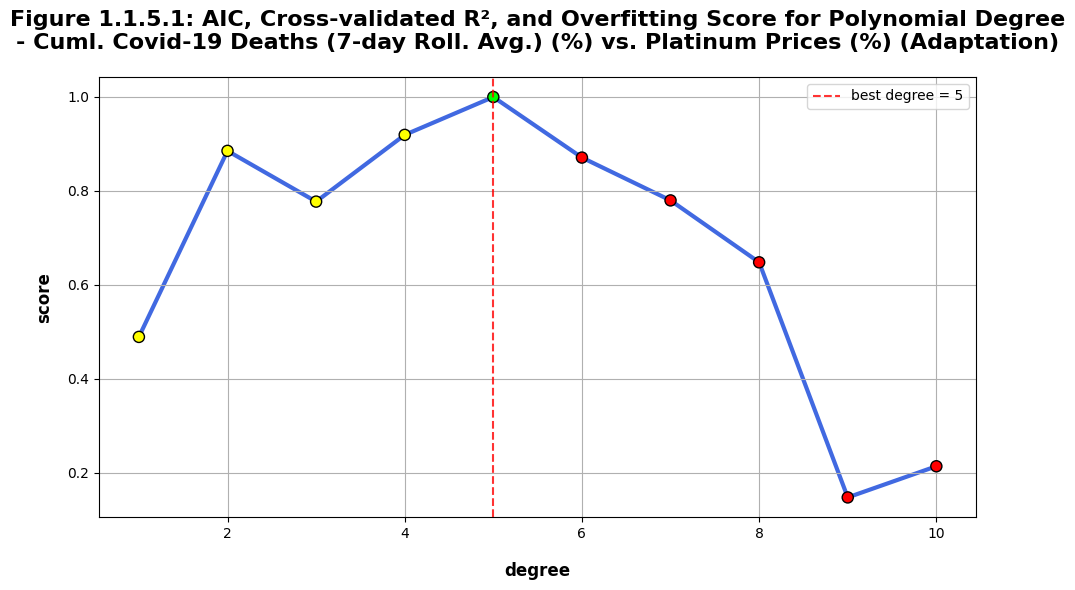

In [65]:
title = 'Figure 1.1.5.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y3**

In [66]:
title = f'Table 1.1.5.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_deaths%,platinum
roll_cml_covid_deaths%,1.00,0.11
platinum,0.11,1.00


### **Scatter Plot: X vs. Y3**

r-value (pearson):	0.111
r-value (spearman):	0.106
tau (kendall):		0.069

p-value (pearson):	0.034
p-value (spearman):	0.044
p-value (kendall):	0.051




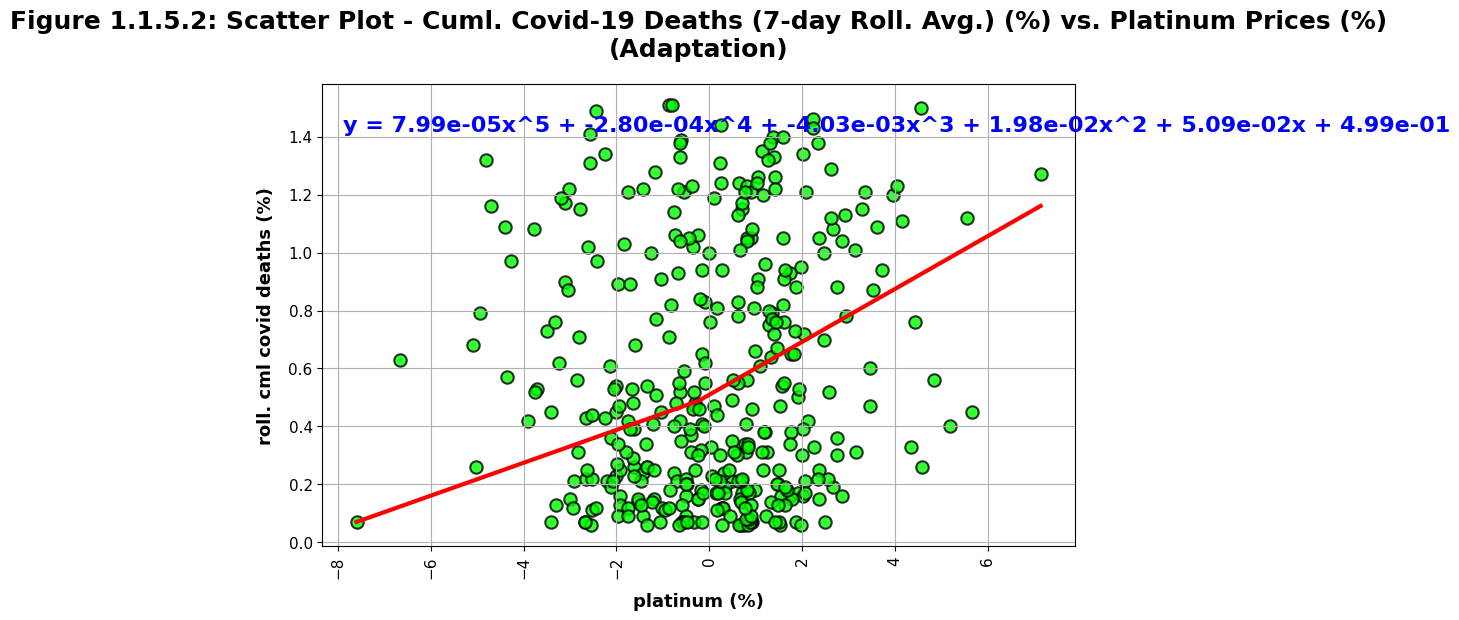

In [67]:
title = 'Figure 1.1.5.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.5.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y3.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y3_series, x_series], title)

### **The Granger Causality Test: X -> Y3**

In [68]:
title = 'Table 1.1.5.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y3_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y3_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y3_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y3.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,4.233038,0.040362,True,True,True,True,high confidence


### **The Granger Causality Test: Y3 -> X**

In [69]:
title = 'Table 1.1.5.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y3.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y3_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y3.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,1.162324,0.281704,False,False,False,False,high confidence
2,0.918879,0.399905,False,False,False,False,high confidence
3,0.619364,0.602857,False,False,False,False,high confidence
4,2.075675,0.083523,False,False,False,False,high confidence
5,1.867137,0.099409,False,False,False,False,high confidence
6,0.922232,0.478893,False,False,False,False,high confidence
7,0.828058,0.564506,False,False,False,False,high confidence
8,1.073635,0.381042,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y3**

In [70]:
results_dict = mathx.fit_var_or_vecm(x_series, y3_series)

x_y3_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_DEATHS% VS. PLATINUM% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.571232, p = 0.099090).

Series 'y' is stationary (ADF = -18.288461, p = 0.000000).

Trace and max-eigenvalue tests agree. One cointegrating relationship detected — VECM is appropriate.

Recommended lag (BIC): 8.
AIC = 14, BIC = 8, HQIC = 8, FPE = 14.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: -0.001070, y: 0.467747. Error correction half-life: inf periods. x - (3.311307) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 1 (magnitude: 6.327717).
Cumulative x→y response: 22.852627.

FEVD (VECM, horizon = 31):
x shocks explain 4.166611% of y's forecast variance (minimal influence).
y's own shocks explain 95.833389% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y3**

In [71]:
title = 'Table 1.1.5.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.685663,6.327717,0.001260,0.009293
2,0.781805,3.518961,0.002571,-0.037753
3,0.735135,1.043335,0.001412,-0.066844
4,0.905747,-1.426949,0.002959,-0.121145
5,1.379499,3.453862,0.003482,-0.063908
6,1.379737,0.172400,0.004004,-0.075542
7,0.987395,-0.273586,0.003680,0.004027
8,1.220754,-1.024540,0.002523,-0.074948


### **Forecast Error Variance Decomposition (FEVD): X vs. Y3**

In [72]:
if irf_bool:
    
    title = 'Table 1.1.5.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

else:

    title = 'Table 1.1.5.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.002564,0.997436,1.000000,0.000000
1,0.019937,0.980063,0.996866,0.003134
2,0.025149,0.974851,0.988809,0.011191
3,0.025516,0.974484,0.988713,0.011287
4,0.025670,0.974330,0.984096,0.015904
5,0.030042,0.969958,0.983227,0.016773
6,0.029901,0.970099,0.981097,0.018903
7,0.029940,0.970060,0.978282,0.021718
8,0.029936,0.970064,0.979375,0.020625


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y3**

In [73]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y3_series, method = corr_method)

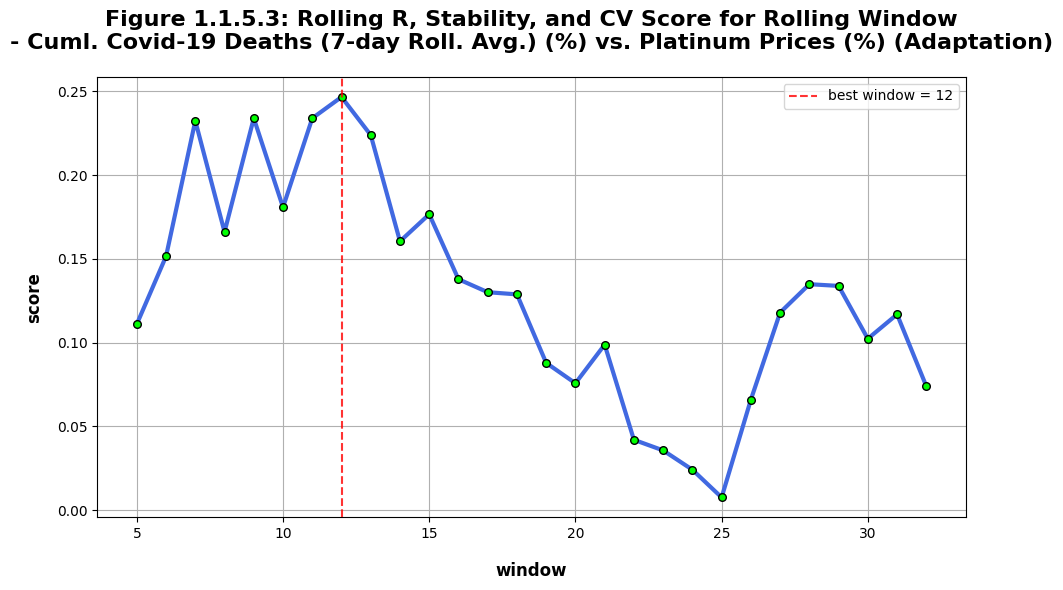

In [74]:
title = 'Figure 1.1.5.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y3**

In [75]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y3_series, best_w, method = corr_method)

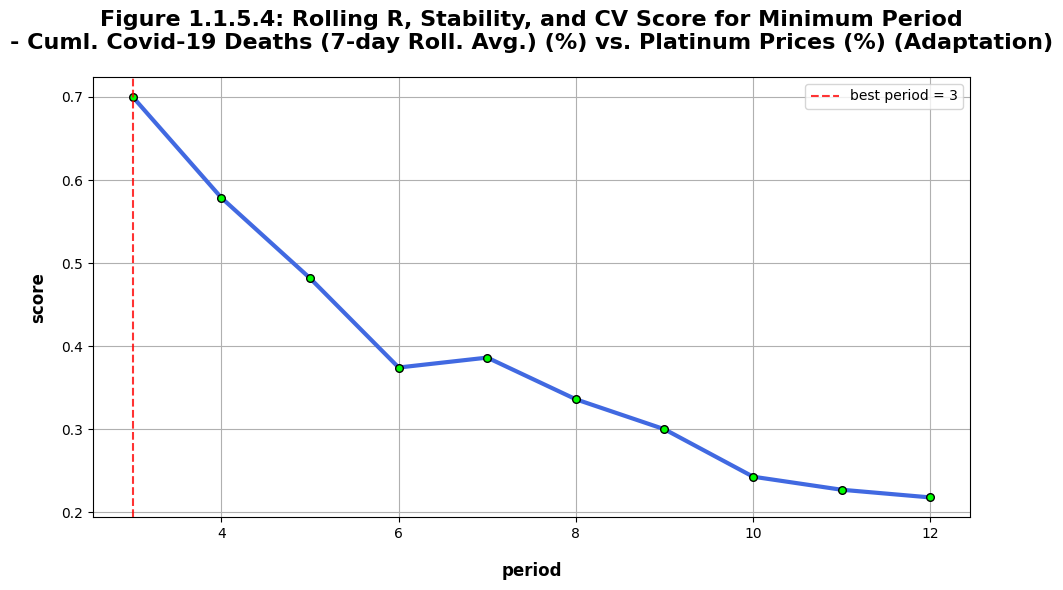

In [76]:
title = 'Figure 1.1.5.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y3**

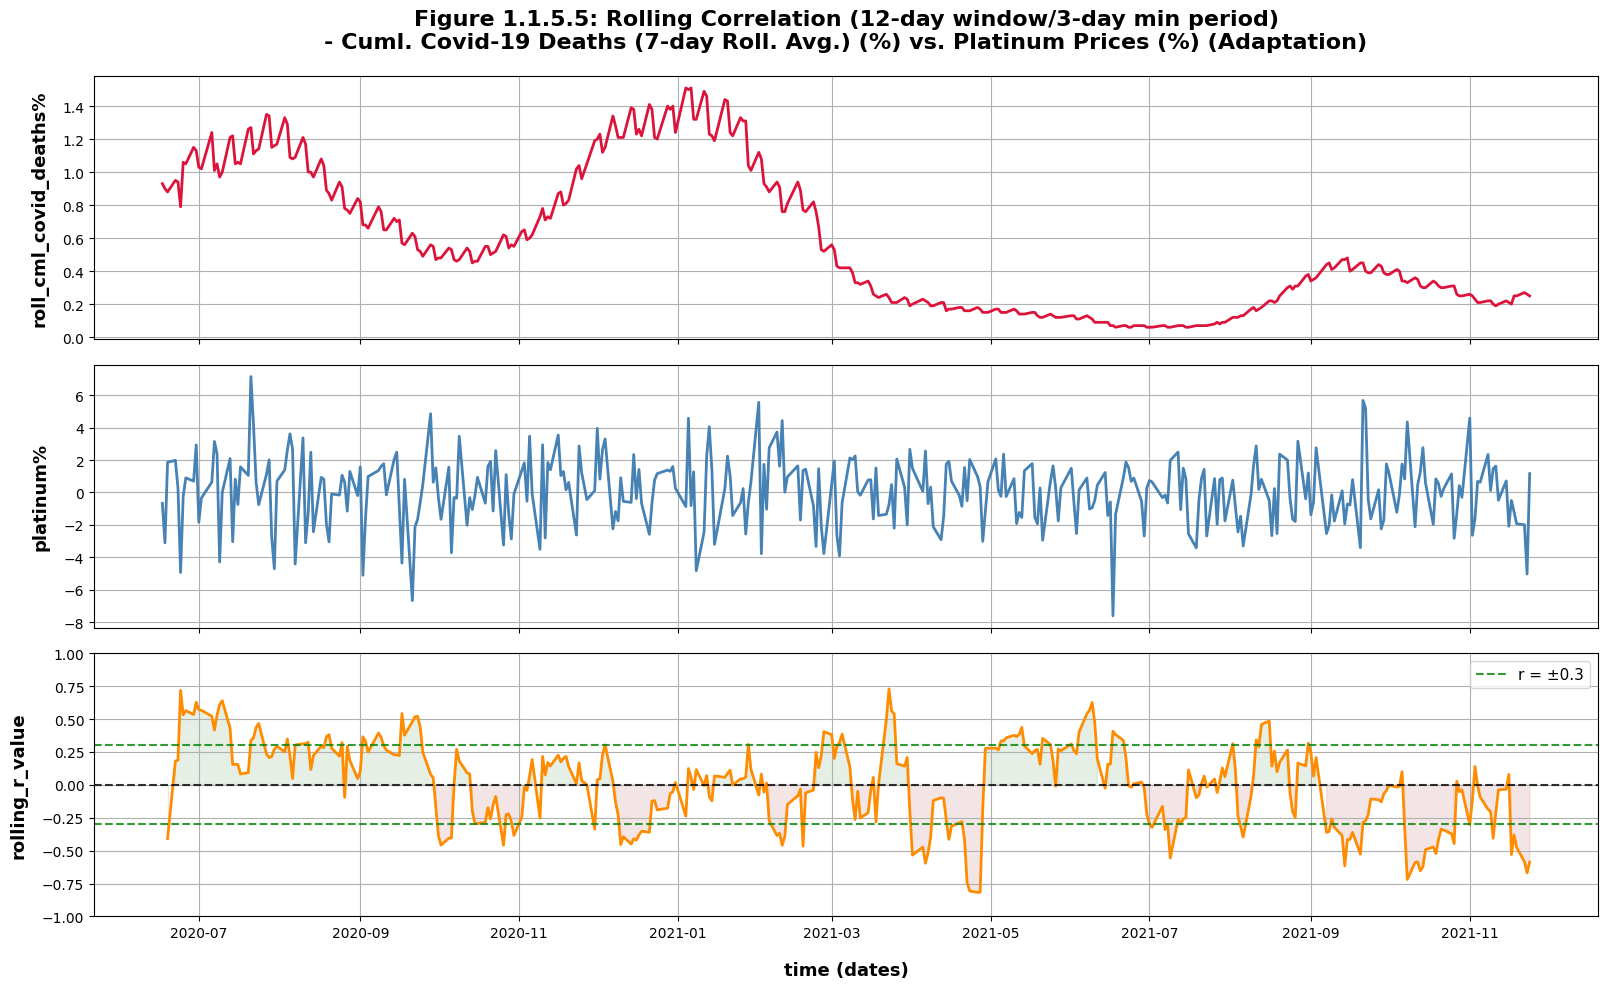

In [77]:
title \
    = f'Figure 1.1.5.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y3_series, title)

### **Lag Correlation: X vs. Y3**

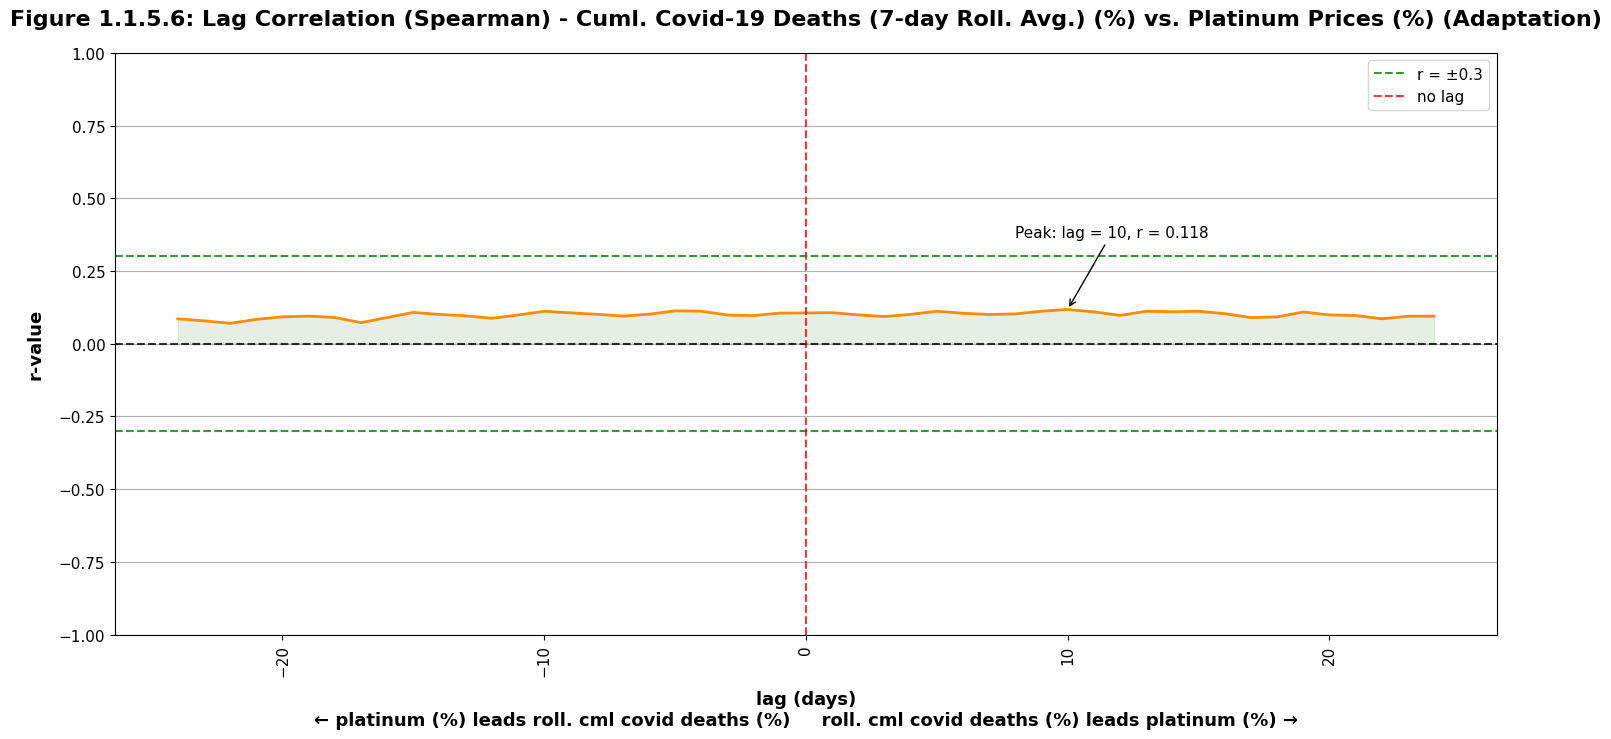

In [78]:
title = f'Figure 1.1.5.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.5.6', PRD, XCAT, YCOL)


v_lag       = int(x_y3_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y3_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y3.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y3_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.5 — `covid_deaths` (%) vs. Y3 Metal Return (%)

**Correlation and Functional Form.** By the third metal, the cross-metal correlation pattern is becoming apparent. If Y3's contemporaneous correlation with COVID death-rate changes is notably stronger than Y1 and Y2, it identifies Y3 as the metal most directly linked to pandemic severity signals in this period. A strong contemporaneous correlation in percentage-change form is particularly meaningful because it has already been stripped of shared trending: both series must be genuinely co-moving on a day-to-day basis around their respective means, not simply trending together over the 536-day window. The scatter plot (Figure 1.1.5.2) provides a visual check for outlier observations that may be disproportionately driving the correlation — for example, single-day extreme metal price moves during the commodity supercycle peak in May 2021.

**Granger Causality.** With three metals analyzed, the X→Y Granger causality results can be evaluated for cross-metal consistency. Three possible patterns emerge: consistent significance across all three (suggesting a broad-based COVID death-rate → metals channel), significance for a subset (suggesting metal-specific sensitivity), or uniformly non-significant (suggesting near-complete decoupling). The F-statistic magnitudes — not just the binary significance decisions — reveal the relative strength of the predictive relationship even when all three are significant, enabling a ranking of which metal's returns were most predictable from COVID death-rate changes.

**VAR/VECM Dynamics.** The IRF for Y3 adds a third data point to the cross-metal comparison of impulse response profiles. If Y3's IRF peak magnitude is the largest of the three metals analyzed so far, it positions Y3 as the most dynamically sensitive to COVID death-rate shocks — meaning a one-standard-deviation increase in death-rate percentage changes produced the largest initial response in this metal's returns. The FEVD X-share for Y3, placed alongside Y1 and Y2, begins to build the picture that Table 1.1.8.5 will eventually summarize: the proportion of each metal's return variance attributable to the COVID signal versus its own internal momentum.

**Rolling and Lag Correlations.** The rolling correlation for Y3 (Figure 1.1.5.5) is particularly informative if it shows a pronounced spike during the Delta wave window (July–September 2021). A visible rolling correlation increase in that sub-period, followed by return to near-zero, would confirm that the COVID death-rate → metal channel reactivated episodically during wave resurgences but was otherwise dormant — a characteristically Adaptation-period pattern where markets were not continuously sensitive to pandemic mortality data but could be temporarily re-engaged by a sufficiently severe variant-driven wave.

---


## **1.1.6: X vs. Y4**

### **Create DataFrame X vs. Y4**

In [79]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y4.value]: y4_series})

logx.log_write_obj(comp_df)

In [80]:
title = f'Table 1.1.6.1: {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y4.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_deaths%,palladium
series,,
2020-06-17,1,-1
2020-06-18,1,-1
2020-06-19,1,-0
2020-06-22,1,2
2020-06-23,1,0
2020-06-24,1,-3
2020-06-25,1,-2
2020-06-26,1,3
2020-06-29,1,2


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y4**

In [81]:
title = 'Table 1.1.6.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y4_series, x_series)

corr_method = mathx.find_opt_corr_method(y4_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-52.54,95.25,1.00,-623.36,1.00,True,1.00
2,0.00,-54.76,99.69,1.00,-622.06,0.91,True,0.95
3,0.00,-55.54,99.28,1.00,-620.09,0.77,True,0.88
4,0.01,-55.64,99.90,1.00,-619.19,0.70,True,0.85
5,0.01,-64.33,114.54,1.00,-617.19,0.56,True,0.78
6,0.01,-440.60,847.08,1.00,-615.25,0.42,True,0.71
7,0.01,"-22,254.04","44,283.05",1.00,-613.51,0.30,True,0.65
8,0.01,"-113,541.56","226,521.82",0.99,-612.23,0.21,True,0.60
9,0.01,"-8,336,712.84","16,668,582.10",0.00,-610.25,0.07,True,0.03
10,0.01,"-960,230.62","1,874,764.68",0.88,-609.34,0.00,True,0.44


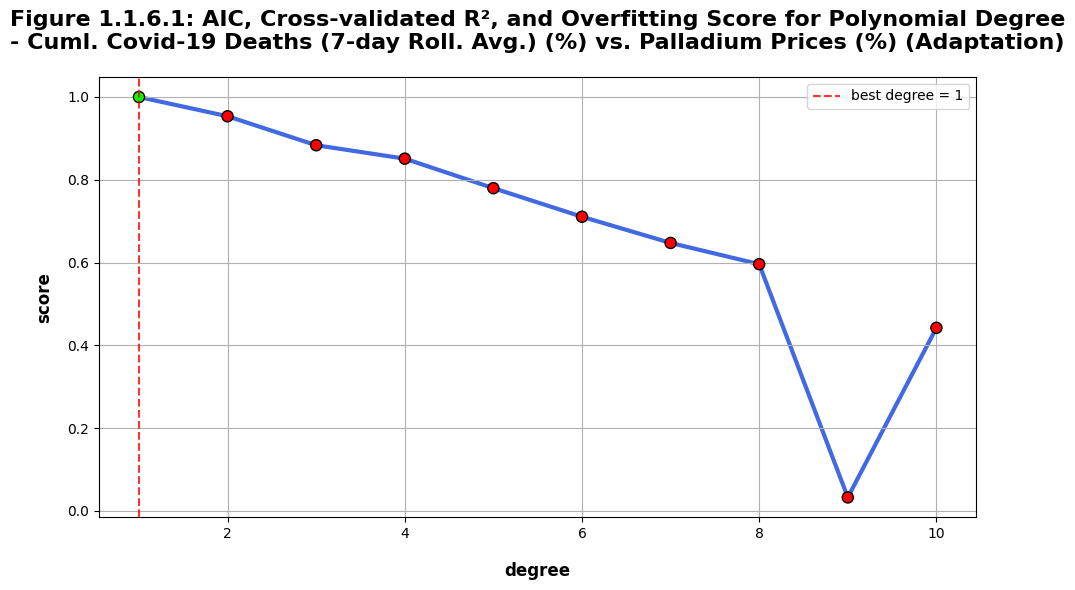

In [82]:
title = 'Figure 1.1.6.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y4**

In [83]:
title = f'Table 1.1.6.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl (comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_deaths%,palladium
roll_cml_covid_deaths%,1.00,0.03
palladium,0.03,1.00


### **Scatter Plot: X vs. Y4**

r-value (pearson):	0.040
r-value (spearman):	0.031
tau (kendall):		0.023

p-value (pearson):	0.446
p-value (spearman):	0.559
p-value (kendall):	0.517




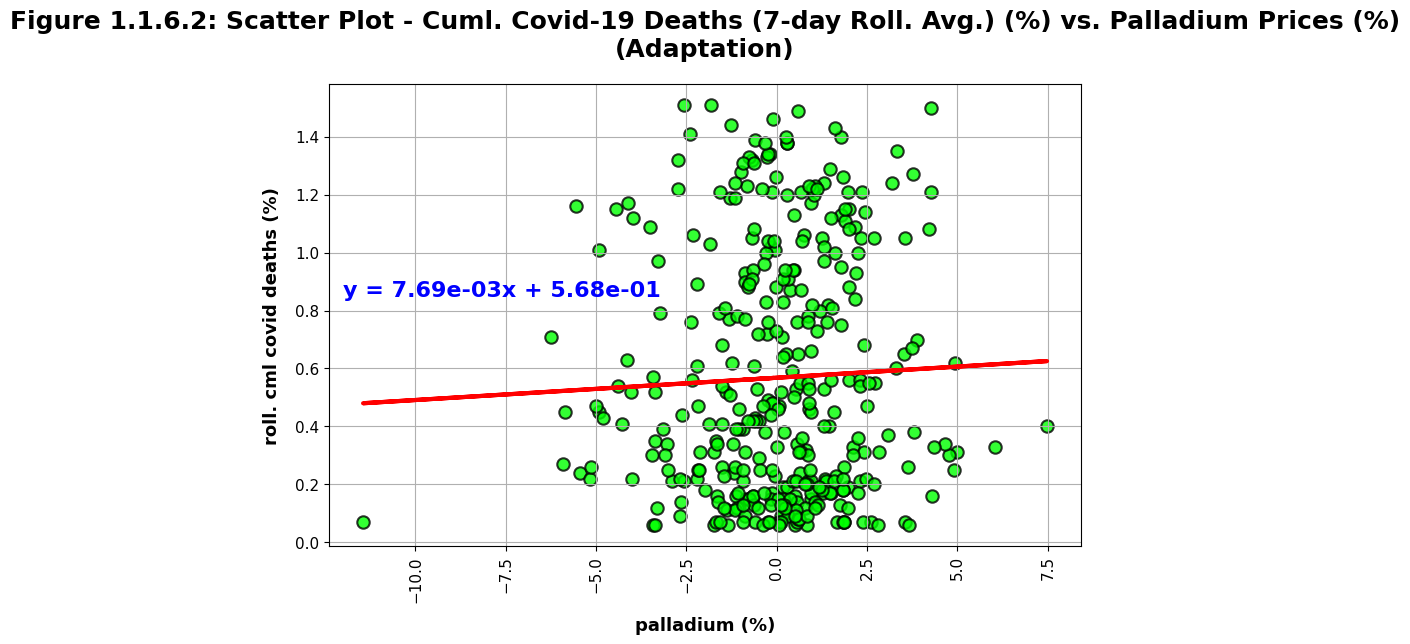

In [84]:
title = 'Figure 1.1.6.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.6.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y4.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y4_series, x_series], title)

### **The Granger Causality Test: X -> Y4**

In [85]:
title = 'Table 1.1.6.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y4_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y4_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y4_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y4.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.406705,0.524051,False,False,False,False,high confidence
2,0.717145,0.488844,False,False,False,False,high confidence
3,1.226231,0.299996,False,False,False,False,high confidence
4,0.914411,0.455574,False,False,False,False,high confidence
5,1.735857,0.125676,False,False,False,False,high confidence
6,1.602636,0.145446,False,False,False,False,high confidence
7,1.605293,0.132749,False,False,False,False,high confidence
8,1.362421,0.211961,False,False,False,False,high confidence


### **The Granger Causality Test: Y4 -> X**

In [86]:
title = 'Table 1.1.6.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y4.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y4_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y4.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.148325,0.700368,False,False,False,False,high confidence
2,0.800028,0.450118,False,False,False,False,high confidence
3,0.663042,0.575242,False,False,False,False,high confidence
4,0.338857,0.851691,False,False,False,False,high confidence
5,0.902144,0.479746,False,False,False,False,high confidence
6,2.175699,0.044855,True,True,True,True,high confidence


### **VAR/VECM Analysis: X vs. Y4**

In [87]:
results_dict = mathx.fit_var_or_vecm(x_series, y4_series)

x_y4_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_DEATHS% VS. PALLADIUM% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.571232, p = 0.099090).

Series 'y' is stationary (ADF = -18.290781, p = 0.000000).

Trace and max-eigenvalue tests agree. One cointegrating relationship detected — VECM is appropriate.

Recommended lag (BIC): 8.
AIC = 15, BIC = 8, HQIC = 8, FPE = 15.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: -0.000342, y: 0.147901. Error correction half-life: inf periods. x - (7.860354) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a negative net response in y.
Peak x→y effect at lag 4 (magnitude: -4.348125).
Cumulative x→y response: -6.656819.

FEVD (VECM, horizon = 31):
x shocks explain 1.896102% of y's forecast variance (minimal influence).
y's own shocks explain 98.103898% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y4**

In [88]:
title = 'Table 1.1.6.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.691288,1.778712,0.002270,0.051296
2,0.780343,-2.705889,0.002160,-0.083434
3,0.733114,0.052125,0.002197,0.060596
4,0.898408,-4.348125,0.001094,-0.014705
5,1.374764,2.375830,0.002538,-0.095281
6,1.367157,-2.870073,0.004502,-0.037680
7,0.974965,-1.295128,0.004749,-0.020596
8,1.212372,-1.032027,0.002074,-0.041405


### **Forecast Error Variance Decomposition (FEVD): X vs. Y4**

In [89]:
if irf_bool:
    
    title = 'Table 1.1.6.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

else:

    title = 'Table 1.1.6.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.000000,1.000000,1.000000,0.000000
1,0.001162,0.998838,0.988957,0.011043
2,0.003434,0.996566,0.985066,0.014934
3,0.003423,0.996577,0.982284,0.017716
4,0.009431,0.990569,0.985243,0.014757
5,0.011141,0.988859,0.986629,0.013371
6,0.013673,0.986327,0.981217,0.018783
7,0.014147,0.985853,0.974736,0.025264
8,0.014374,0.985626,0.977069,0.022931


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y4**

In [90]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y4_series, method = corr_method)

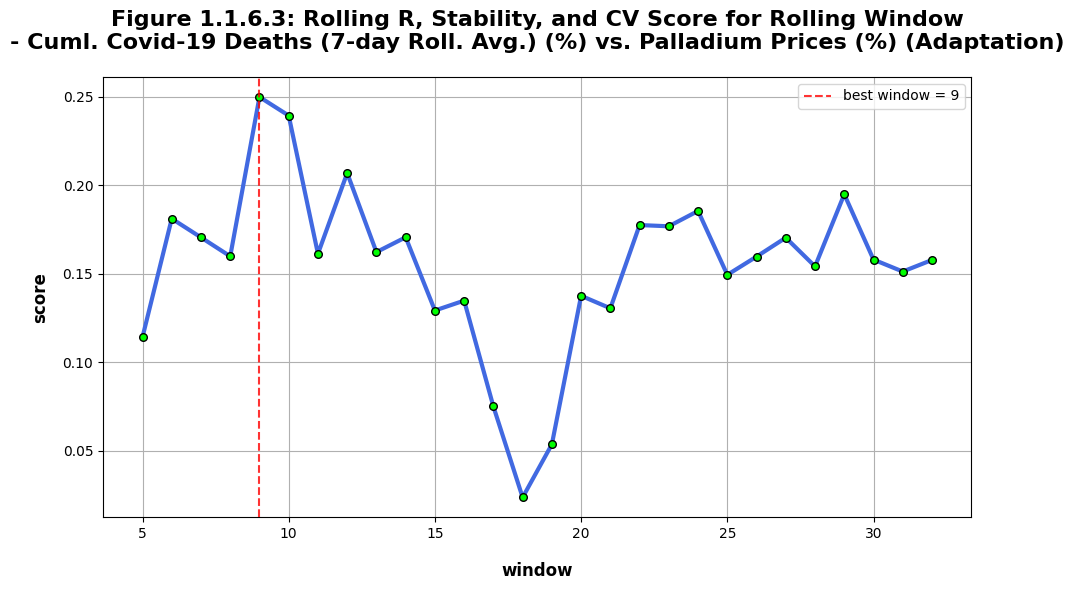

In [91]:
title = 'Figure 1.1.6.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y4**

In [92]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y4_series, best_w, method = corr_method)

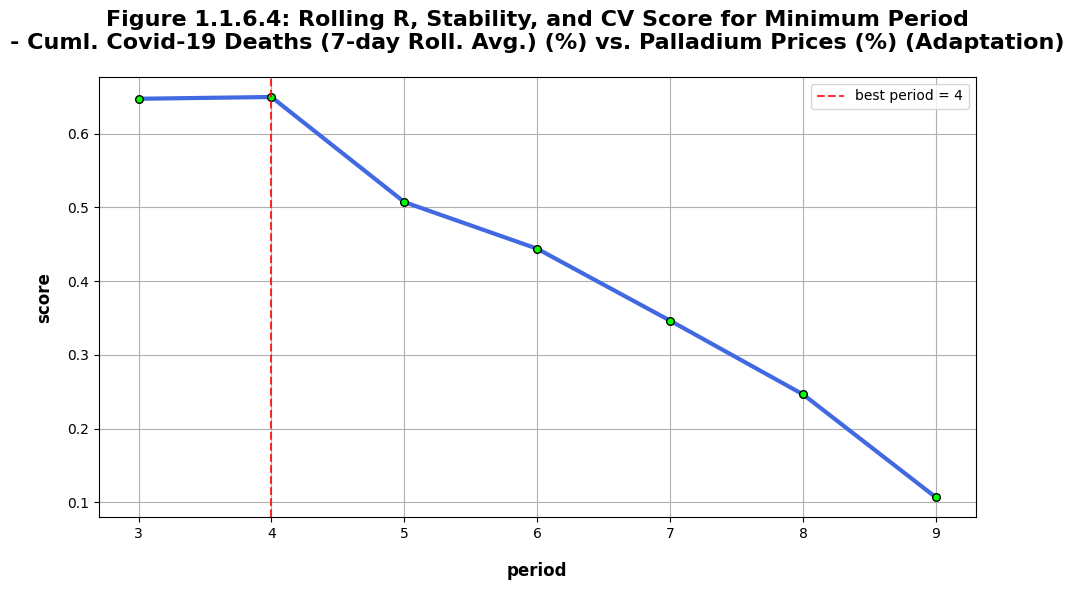

In [93]:
title = 'Figure 1.1.6.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y4**

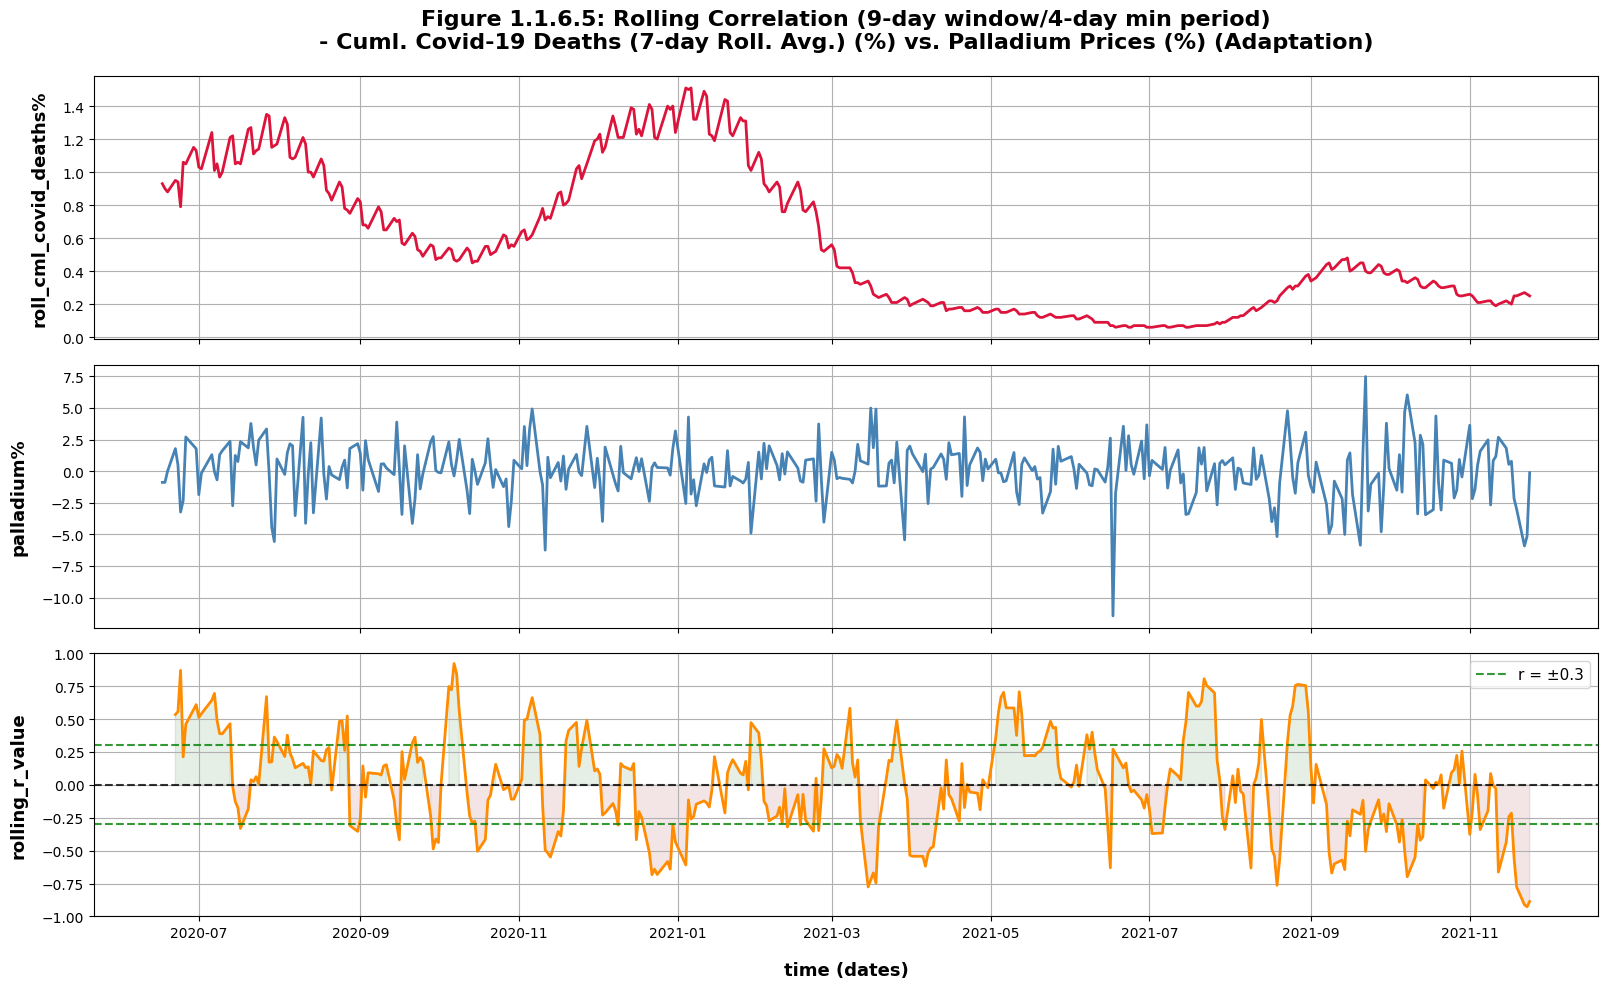

In [94]:
title \
    = f'Figure 1.1.6.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y4_series, title)

### **Lag Correlation: X vs. Y4**

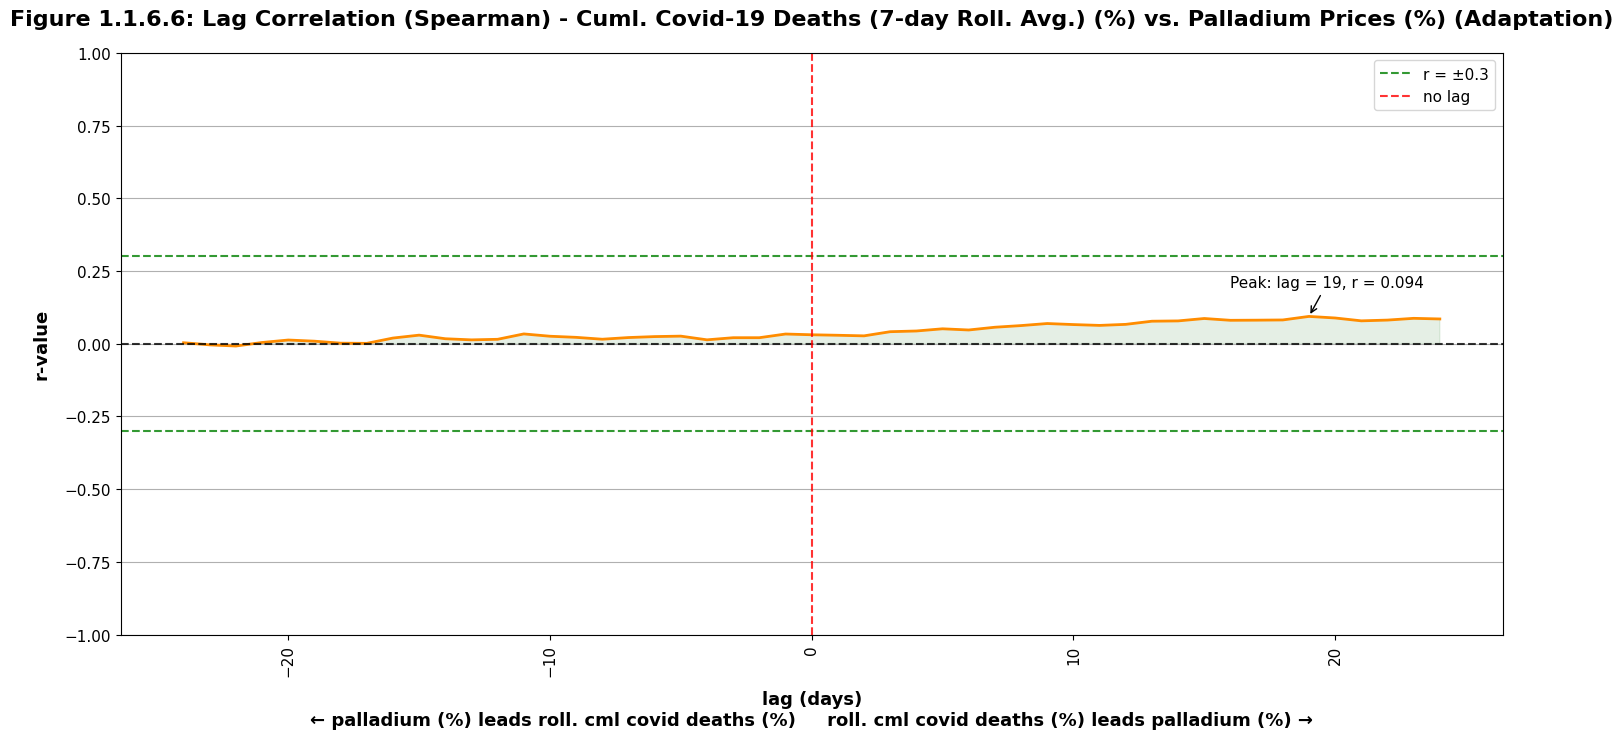

In [95]:
title = f'Figure 1.1.6.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.6.6', PRD, XCAT, YCOL)


v_lag       = int(x_y4_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y4_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y4.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y4_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.6 — `covid_deaths` (%) vs. Y4 Metal Return (%)

**Correlation and Functional Form.** Y4's polynomial degree and correlation results extend the cross-metal picture to four metals. The optimal polynomial degree for each metal's relationship with COVID death-rate changes reflects the functional form of market responses to pandemic signals. If three of the four metals analyzed so far have been best fit by degree 1 (linear) while Y4 requires a higher degree, it suggests that Y4's relationship with pandemic mortality is nonlinear — potentially reflecting a threshold effect where only sufficiently large changes in the death rate trigger price responses, with smaller changes being ignored by the market. This is consistent with the Adaptation period's normalized pandemic environment, where incremental increases in a steadily rising cumulative death count may have been discounted until exceeding a threshold that re-engaged risk management responses.

**Granger Causality.** The Granger causality results for Y4 (Tables 1.1.6.4 and 1.1.6.5) add a fourth pair to the emerging cross-metal causality pattern. At this point in the analysis, it is possible to assess whether the significant or non-significant X→Y result is consistent with an identifiable characteristic of Y4 — for example, whether it is a precious or industrial metal, and whether the result fits the theoretical predictions about which channel should dominate for each metal type. A reversal of the pattern seen in Y1–Y3 (e.g., Y4 is the first to show Y→X significance) would be a notable finding, warranting a discussion of whether commodity prices in this metal class were leading pandemic mortality indicators through economic activity channels.

**VAR/VECM Dynamics.** The VAR/VECM model for Y4 completes the fourth pair of IRF and FEVD results. If Y4's FEVD X-share is meaningfully higher than the others, it would position Y4 as the metal whose return variance was most attributable to COVID death-rate fluctuations — making it the strongest candidate for inclusion in a downstream model that uses the COVID mortality signal as an explanatory variable. Conversely, a very low X-share for Y4 while the Granger test was significant would indicate that COVID death-rate changes have predictive power for Y4 but explain little of its total variance — a technically significant but practically modest relationship.

**Rolling and Lag Correlations.** If Y4's rolling correlation (Figure 1.1.6.5) shows a different temporal profile than Y1–Y3 — for example, a sustained positive correlation in the first half of the Adaptation window followed by sign reversal in the second half — it would suggest that the economic channel linking COVID deaths to Y4's returns changed over the course of the period. This could reflect the transition from a supply-disruption-dominated environment in 2020 to an inflation-and-demand-recovery-dominated environment in 2021, with different implications for the sign of the death-rate/metal relationship.

---


## **1.1.7: X vs. Y5**

### **Create DataFrame X vs. Y5**

In [96]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y5.value]: y5_series})

logx.log_write_obj(comp_df)

In [97]:
title = f'Table 1.1.7.1: {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y5.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_deaths%,copper
series,,
2020-06-17,1,1
2020-06-18,1,-2
2020-06-19,1,2
2020-06-22,1,0
2020-06-23,1,1
2020-06-24,1,-2
2020-06-25,1,1
2020-06-26,1,1
2020-06-29,1,-0


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y5**

In [98]:
title = 'Table 1.1.7.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y5_series, x_series)

corr_method = mathx.find_opt_corr_method(y5_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.01,-51.84,93.82,0.13,-628.25,0.00,True,0.06
2,0.09,-47.14,85.99,0.87,-653.38,1.00,True,0.93
3,0.09,-47.18,85.97,0.86,-651.40,0.92,True,0.89
4,0.09,-47.02,85.65,0.89,-650.01,0.87,True,0.88
5,0.09,-46.86,85.39,0.91,-648.81,0.82,True,0.87
6,0.09,-47.07,85.46,0.88,-646.93,0.74,True,0.81
7,0.09,-47.45,85.63,0.82,-644.99,0.67,True,0.74
8,0.10,-47.04,84.19,0.88,-645.99,0.71,True,0.80
9,0.10,-52.66,81.80,0.00,-644.06,0.63,True,0.31
10,0.10,-46.31,83.52,1.00,-644.43,0.64,True,0.82


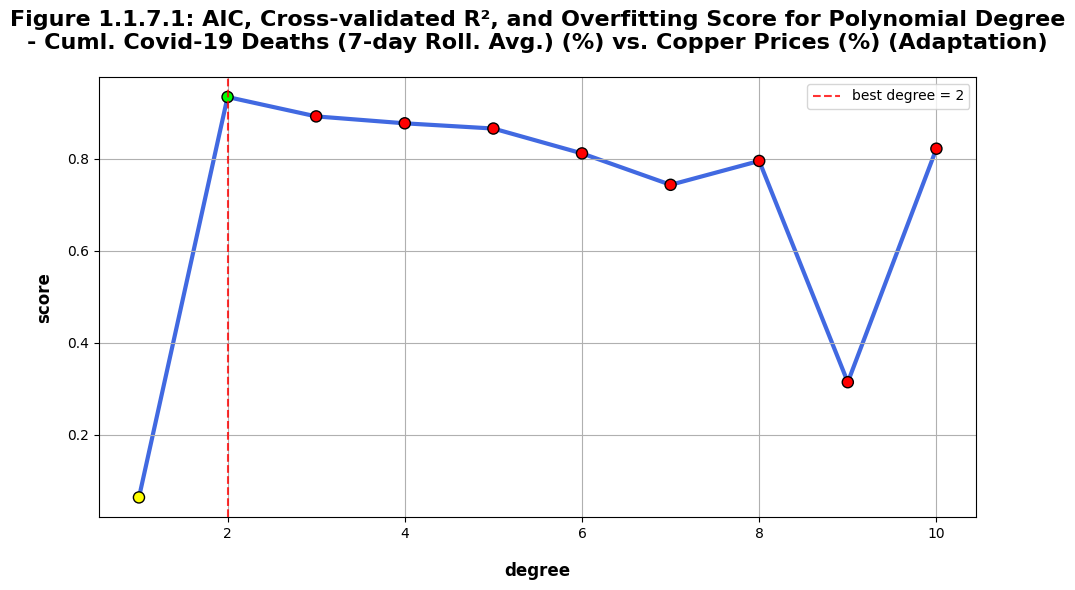

In [99]:
title = 'Figure 1.1.7.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y5**

In [100]:
title = f'Table 1.1.7.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_deaths%,copper
roll_cml_covid_deaths%,1.00,0.12
copper,0.12,1.00


### **Scatter Plot: X vs. Y5**

r-value (pearson):	0.122
r-value (spearman):	0.124
tau (kendall):		0.080

p-value (pearson):	0.020
p-value (spearman):	0.018
p-value (kendall):	0.023




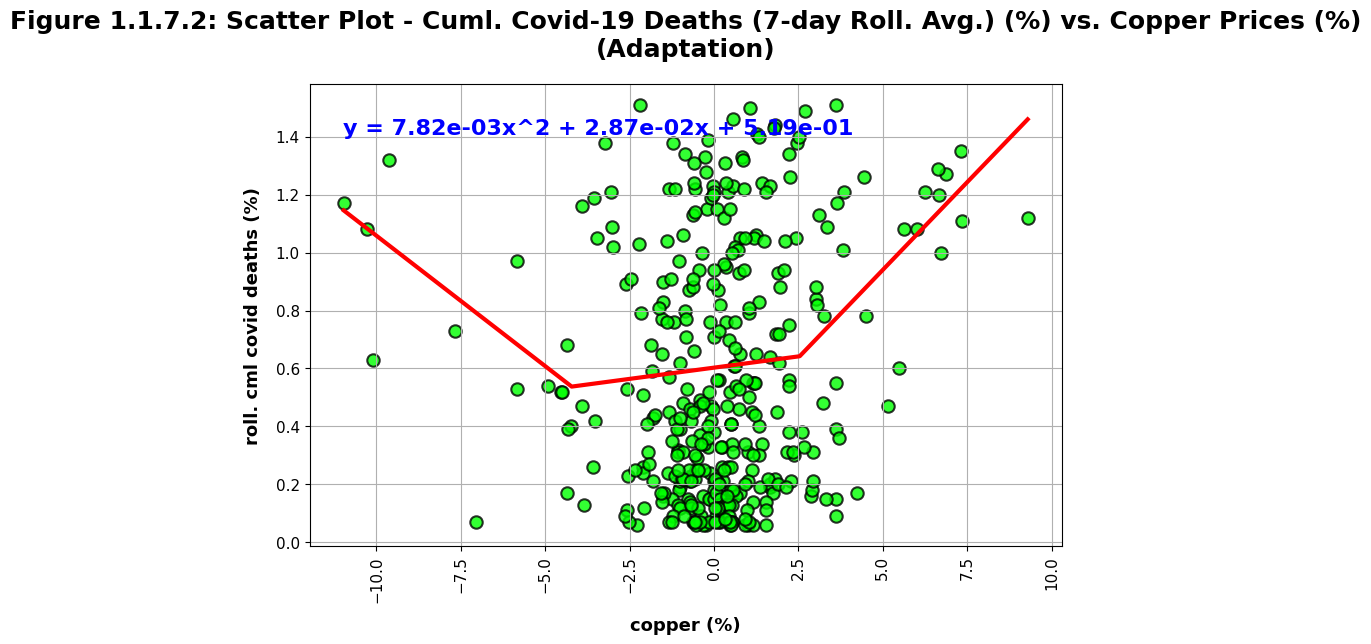

In [101]:
title = 'Figure 1.1.7.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.7.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y5.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y5_series, x_series], title)

### **The Granger Causality Test: X -> Y5**

In [102]:
title = 'Table 1.1.7.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y5_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y5_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y5_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y5.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,5.279499,0.022149,True,True,True,True,high confidence


### **The Granger Causality Test: Y5 -> X**

In [103]:
title = 'Table 1.1.7.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y5.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y5_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y5.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.698212,0.403938,False,False,False,False,high confidence
2,1.642124,0.195023,False,False,False,False,high confidence
3,0.505549,0.678687,False,False,False,False,high confidence
4,0.239926,0.915634,False,False,False,False,high confidence
5,0.591573,0.706456,False,False,False,False,high confidence
6,0.345349,0.912404,False,False,False,False,high confidence
7,0.833823,0.559771,False,False,False,False,high confidence
8,0.608800,0.770495,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y5**

In [104]:
results_dict = mathx.fit_var_or_vecm(x_series, y5_series)

x_y5_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_DEATHS% VS. COPPER% ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.571232, p = 0.099090).

Series 'y' is stationary (ADF = -22.314382, p = 0.000000).

Trace and max-eigenvalue tests agree. One cointegrating relationship detected — VECM is appropriate.

Recommended lag (BIC): 8.
AIC = 16, BIC = 8, HQIC = 13, FPE = 16.

VECM(lag = 7, rank = 1) fitted. Adjustment speeds — x: 0.000917, y: 0.428049. Error correction half-life: inf periods. x - (3.039357) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 5 (magnitude: 6.752147).
Cumulative x→y response: 23.056212.

FEVD (VECM, horizon = 31):
x shocks explain 3.244149% of y's forecast variance (minimal influence).
y's own shocks explain 96.755851% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y5**

In [105]:
title = 'Table 1.1.7.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y5.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.696849,0.931044,-0.001100,-0.163287
2,0.788221,0.884906,-0.001122,0.024642
3,0.736931,0.994326,-0.001607,-0.026969
4,0.902604,-0.502355,-0.000915,-0.077719
5,1.373297,6.752147,-0.000595,-0.006807
6,1.378073,-2.147159,-0.001871,-0.032723
7,0.987797,1.596527,-0.003126,0.015199
8,1.216069,0.030916,-0.002182,0.028298


### **Forecast Error Variance Decomposition (FEVD): X vs. Y5**

In [106]:
if irf_bool:
    
    title = 'Table 1.1.7.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

else:

    title = 'Table 1.1.7.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.005286,0.994714,1.000000,0.000000
1,0.005211,0.994789,0.997422,0.002578
2,0.005530,0.994470,0.996444,0.003556
3,0.005731,0.994269,0.994322,0.005678
4,0.005891,0.994109,0.995134,0.004866
5,0.017749,0.982251,0.996774,0.003226
6,0.019116,0.980884,0.996467,0.003533
7,0.019867,0.980133,0.993668,0.006332
8,0.019881,0.980119,0.993552,0.006448


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y5**

In [107]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y5_series, method = corr_method)

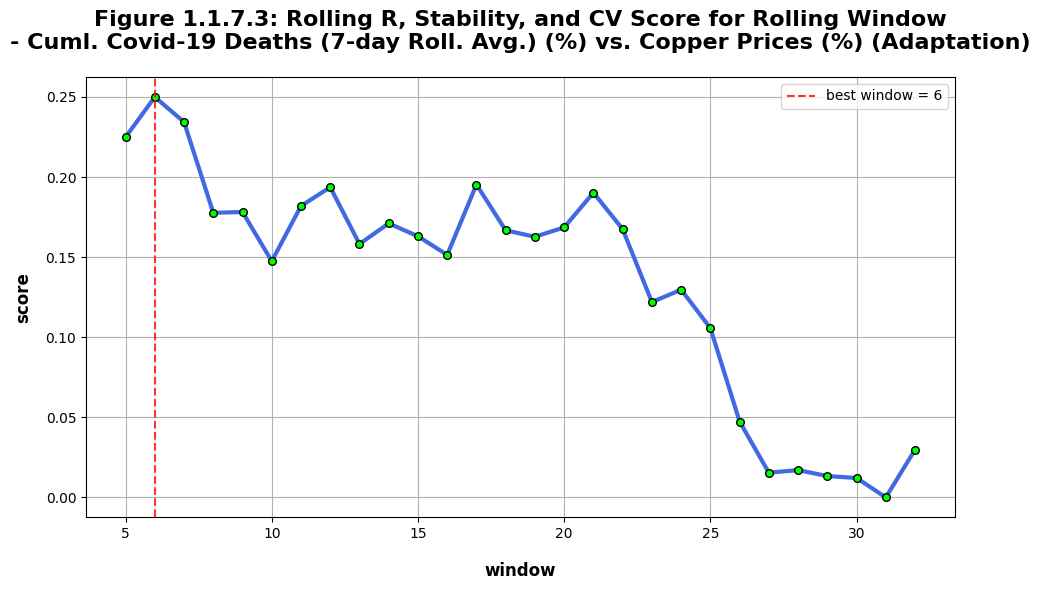

In [108]:
title = 'Figure 1.1.7.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y5**

In [109]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y5_series, best_w, method = corr_method)

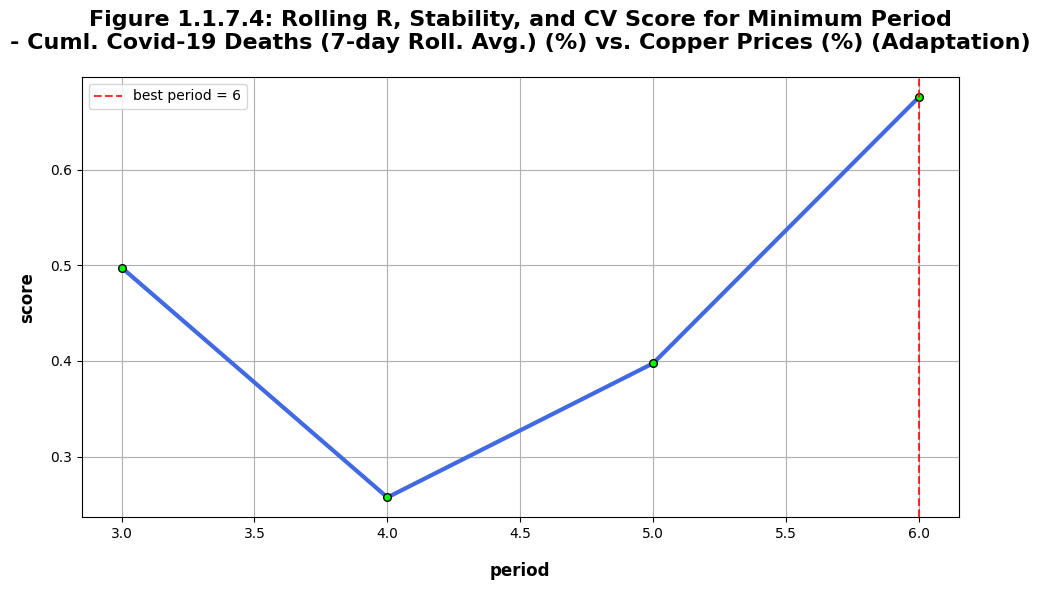

In [110]:
title = 'Figure 1.1.7.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y5**

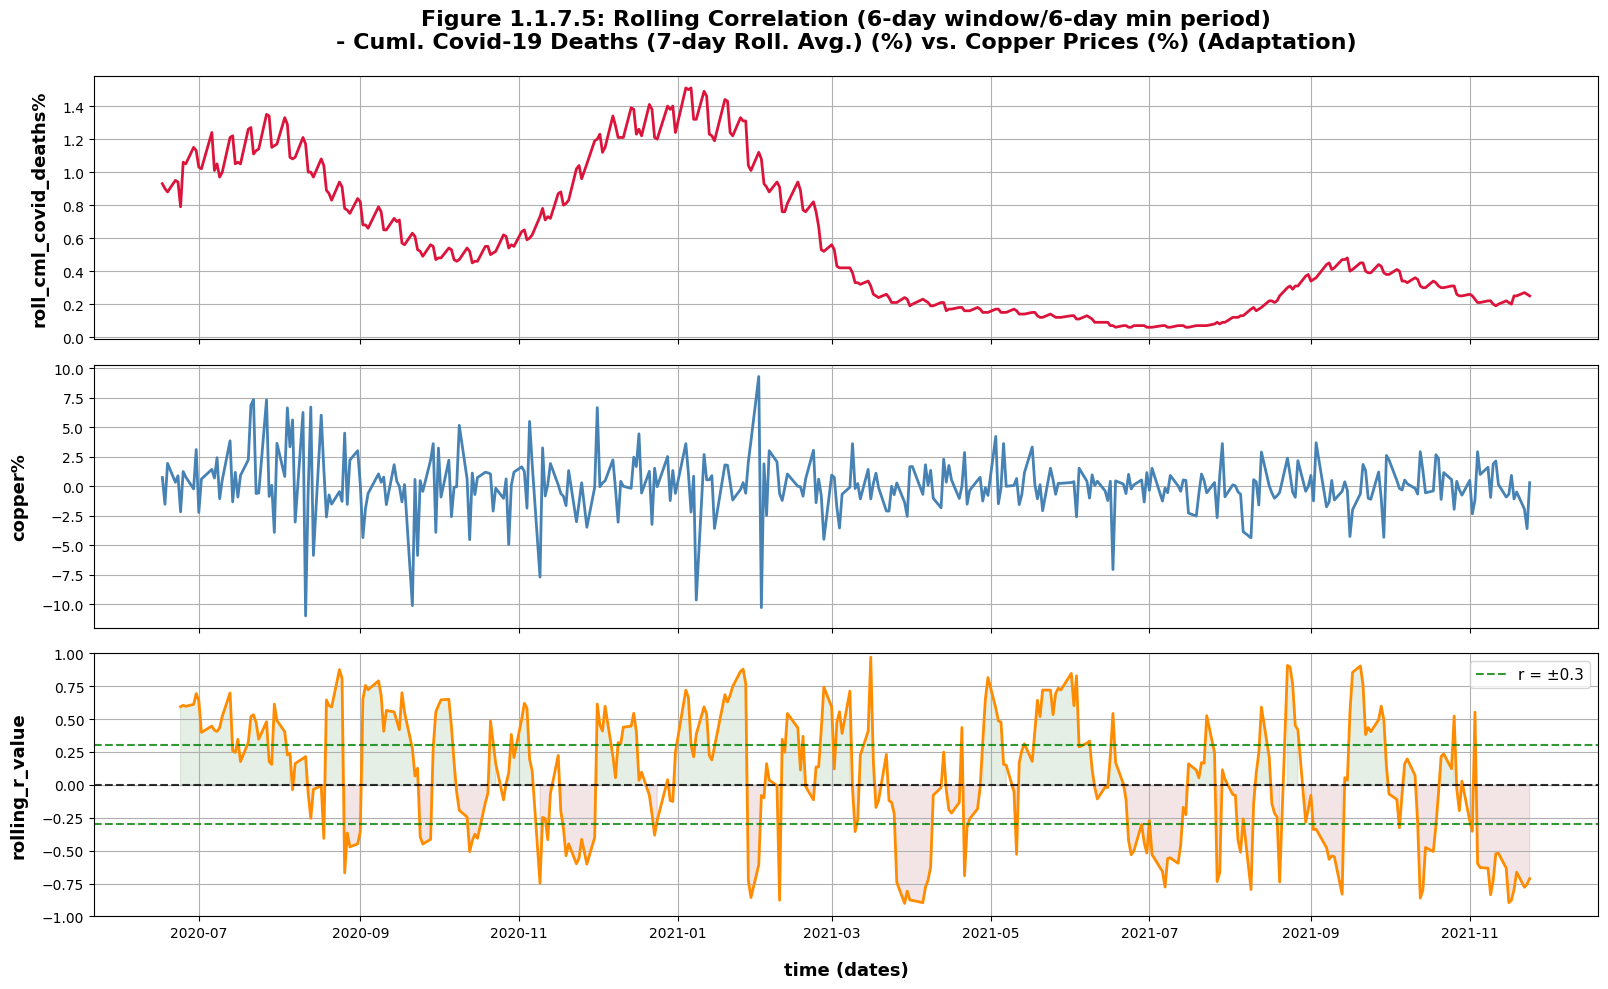

In [111]:
title \
    = f'Figure 1.1.7.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y5_series, title)

### **Lag Correlation: X vs. Y5**

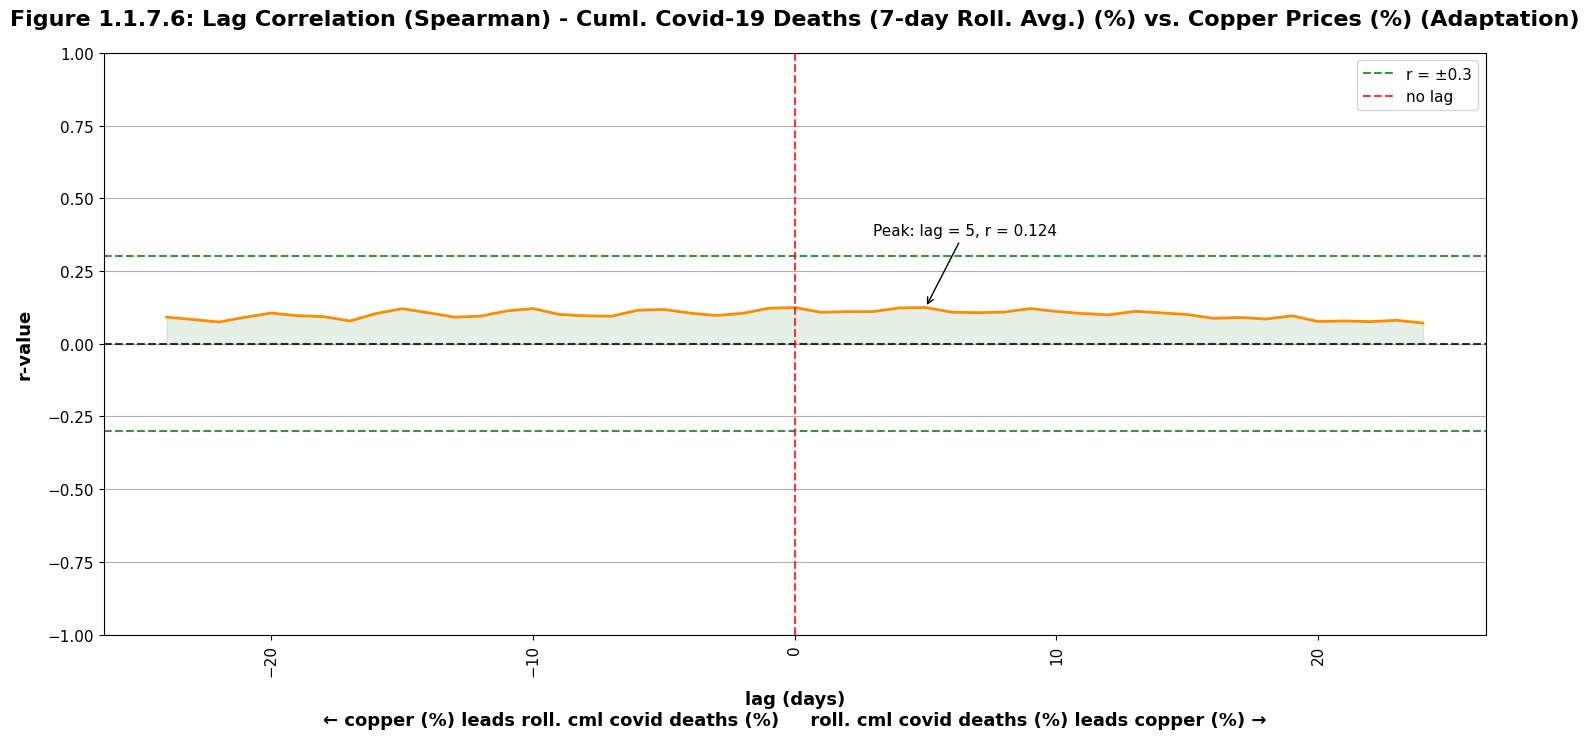

In [112]:
title = f'Figure 1.1.7.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.7.6', PRD, XCAT, YCOL)


v_lag       = int(x_y5_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y5_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y5.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y5_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.7 — `covid_deaths` (%) vs. Y5 Metal Return (%)

**Correlation and Functional Form.** Y5 completes the individual metal analyses and provides the final data point for the cross-metal correlation comparison. The full set of polynomial degrees and correlation coefficients — spanning Y1 through Y5 — will be consolidated in Table 1.1.8.2. Y5's position in that ranking (strongest or weakest contemporaneous correlation with COVID death-rate changes) determines whether it is the metals market segment most or least linked to pandemic severity signals during the Adaptation period. A degree-1 fit with a low but statistically meaningful correlation would be the most interpretable result: a linear, albeit modest, relationship between death-rate percentage changes and metal returns that reflects the attenuated but persistent COVID signal in this phase.

**Granger Causality.** The Granger causality results for Y5 (Tables 1.1.7.4 and 1.1.7.5) complete the 5×2 causality matrix (five metals, two directions each) that Table 1.1.8.4 will assemble. The question of whether the X→Y direction is significant for a majority of the five metals — or only for a minority — is central to the overall conclusion of this notebook. Significance for three or more metals would constitute broad-based evidence of COVID death-rate → metal return predictability during the Adaptation period; significance for only one or two would suggest metal-specific idiosyncratic sensitivity rather than a systemic channel.

**VAR/VECM Dynamics.** Y5's IRF and FEVD results finalize the five-row comparison in Table 1.1.8.5. If Y5's FEVD X-share is the largest of all five metals, it positions Y5 as the metal whose Adaptation-period returns were most explained by COVID mortality dynamics — a key finding for portfolio allocation and risk management in pandemic-affected commodity markets. If Y5's X-share is consistent with Y1–Y4 (all low but non-zero), it confirms a broad but modest COVID death-rate influence on the metals complex as a whole.

**Rolling and Lag Correlations.** The lag correlation for Y5 (Figure 1.1.7.6) completes the individual lag profiles. Its peak lag, read alongside Y1–Y4, will indicate whether the five metals incorporated COVID death-rate information at similar speeds or at materially different lags. Consistent peak lags across all five metals (e.g., all peaking at 3–7 days) would suggest a single common information processing mechanism — perhaps pandemic news disseminating through commodity futures markets with a fixed delay. Divergent peak lags across metals would suggest that different market microstructures or investor bases process the same COVID information on different timescales, which has direct implications for the lag structure used in any downstream predictive model.

---


## **1.1.8: Summary Results: X vs. Y**

### **Assemble Series Dictionaries: X vs. Y**

In [113]:
if YPCT:

    ttl_dict \
        = {XCAT:                   x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Correlations: X vs. Y**

In [114]:
title = f'Table 1.1.8.1: Correlations ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.best_method_corr_matrix(pd.DataFrame(ttl_dict))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}')

,roll_cml_covid_deaths%,gold%,silver%,platinum%,palladium%,copper%
series,,,,,,
roll_cml_covid_deaths%,1.000,0.054,0.124,0.106,0.031,0.124
gold%,0.054,1.000,0.793,0.587,0.409,0.793
silver%,0.124,0.793,1.000,0.631,0.489,1.000
platinum%,0.106,0.587,0.631,1.000,0.528,0.631
palladium%,0.031,0.409,0.489,0.528,1.000,0.489
copper%,0.124,0.793,1.000,0.631,0.489,1.000


### **Polynomial Degrees for Correlations Summary: X vs. Y**

In [115]:
title = 'Table 1.1.8.2: Polynomial Degrees for Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.opt_degree_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['train_r2', 'cv_r2', 'cv_r2_std'])

,best_degree,coefficients,intercept,train_r2,cv_r2,cv_r2_std,aic,linearity_adequate
series,,,,,,,,
gold%,2,"['5.82e-01', '-7.15e-01']",1.28e-01,0.0081,-0.0287,0.0285,25.55,True
silver%,1,['6.98e-01'],-2.88e-01,0.0149,-0.0100,0.0132,644.79,True
platinum%,1,['5.45e-01'],-2.49e-01,0.0124,0.0027,0.0055,532.28,True
palladium%,1,['2.08e-01'],-1.05e-01,0.0016,-0.0308,0.0299,581.02,True
copper%,1,['6.98e-01'],-2.88e-01,0.0149,-0.0100,0.0132,644.79,True


### **The Engle-Granger Cointegration Test: X vs. Y**

In [116]:
title = 'Table 1.1.8.3: The Engle-Granger Cointegration Test ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.eg_coint_test_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.6f}', subset = ['p_value'])

,coint_stat,p_value,trend_desc,autolag,passes_mean_test,passes_trend_test,cointegrated
series,,,,,,,
gold%,-19.61,0.000000,no trend,AIC,True,True,True
silver%,-22.56,0.000000,no trend,AIC,True,True,True
platinum%,-18.43,0.000000,no trend,AIC,True,True,True
palladium%,-18.33,0.000000,no trend,AIC,True,True,True
copper%,-22.56,0.000000,no trend,AIC,True,True,True


### **The Granger Causality Test Summary: X vs. Y**

In [117]:
title = 'Table 1.1.8.4: The Granger Causality Test Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df = pd.DataFrame(grngr_bst_list)

test_df['series'] = list(grngr_nm_list)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['f_p_value', 'chi2_p_value', 'lrtest_p_value', 'params_f_p_value'])

,f_statistic,chi2_statistic,lrtest_statistic,params_f_statistic,f_p_value,chi2_p_value,lrtest_p_value,params_f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
series,,,,,,,,,,,,,
roll_cml_covid_deaths% -> gold,1.80,11.19,11.02,1.80,0.0987,0.0826,0.0877,0.0987,False,False,False,False,high confidence
gold -> roll_cml_covid_deaths%,1.14,5.90,5.85,1.14,0.3370,0.3163,0.3211,0.3370,False,False,False,False,high confidence
roll_cml_covid_deaths% -> silver,5.28,5.32,5.28,5.28,0.0221,0.0210,0.0215,0.0221,True,True,True,True,high confidence
silver -> roll_cml_covid_deaths%,1.64,3.33,3.31,1.64,0.1950,0.1892,0.1906,0.1950,False,False,False,False,high confidence
roll_cml_covid_deaths% -> platinum,4.23,4.27,4.24,4.23,0.0404,0.0388,0.0394,0.0404,True,True,True,True,high confidence
platinum -> roll_cml_covid_deaths%,2.08,8.51,8.42,2.08,0.0835,0.0744,0.0775,0.0835,False,False,False,False,high confidence
roll_cml_covid_deaths% -> palladium,1.74,8.95,8.84,1.74,0.1257,0.1110,0.1155,0.1257,False,False,False,False,high confidence
palladium -> roll_cml_covid_deaths%,2.18,13.54,13.30,2.18,0.0449,0.0352,0.0386,0.0449,True,True,True,True,high confidence
roll_cml_covid_deaths% -> copper,5.28,5.32,5.28,5.28,0.0221,0.0210,0.0215,0.0221,True,True,True,True,high confidence


### **VAR/VECM Analysis Summary: X vs. Y**

In [118]:
title = 'Table 1.1.8.5: VAR/VECM Analysis Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df \
    = pd.concat \
        ([x_y1_analysis_df, 
          x_y2_analysis_df,
          x_y3_analysis_df,
          x_y4_analysis_df,
          x_y5_analysis_df])

test_df['series'] = list(comp_dict)

test_df = test_df.dropna(how = 'all', axis = 1)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['fevd_x_share_in_y', 'fevd_y_own_share']) \
    .format('{:,.6f}', subset = ['irf_peak_mag'])

,model_type,x_stationary,y_stationary,coint_rank,lag,is_stable,irf_peak_lag,irf_peak_mag,irf_sign,fevd_x_share_in_y,fevd_y_own_share,half_life
series,,,,,,,,,,,,
gold%,VECM,False,True,1,7,False,5,2.279831,positive,0.0213,0.9787,inf
silver%,VECM,False,True,1,7,False,5,6.752147,positive,0.0324,0.9676,inf
platinum%,VECM,False,True,1,7,True,1,6.327717,positive,0.0417,0.9583,inf
palladium%,VECM,False,True,1,7,True,4,-4.348125,negative,0.0190,0.9810,inf
copper%,VECM,False,True,1,7,False,5,6.752147,positive,0.0324,0.9676,inf


### **Rolling Windows Summary: X vs. Y**

In [119]:
title = 'Table 1.1.8.6: Rolling Windows Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df, w_array = mathx.opt_window_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'ac1', 'ac1_penalty'])

,optimal_window,rc_mean,rc_std,pct_significant%,cv_mean,cv_std,is_stable,ac1,ac1_penalty,score%
series,,,,,,,,,,
gold%,10,0.0571,0.3251,6.18,0.2697,0.0332,False,0.8230,0.0000,25.00
silver%,6,0.0993,0.4577,8.61,0.3988,0.0640,False,0.7748,0.0000,25.00
platinum%,12,-0.0098,0.3017,6.21,0.2429,0.0723,False,0.8559,0.0059,24.67
palladium%,9,-0.0231,0.3460,6.44,0.2788,0.0252,False,0.7854,0.0000,25.00
copper%,6,0.0993,0.4577,8.61,0.3988,0.0640,False,0.7748,0.0000,25.00


### **Rolling Minimum Periods Summary: X vs. Y**

In [120]:
title = 'Table 1.1.8.7: Rolling Minimum Periods Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

roll_corr_df = mathx.opt_min_period_summ_df(x_series, comp_dict, w_array)

pandasx.rtn_fmt_tbl(roll_corr_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['warmup_cost', 'stability', 'convergence']) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'nan_fraction'])

,min_period,window,rc_mean,rc_std,cv_mean,cv_std,nan_fraction,pct_significant%,warmup_cost,stability,convergence,score%
series,,,,,,,,,,,,
gold%,3,10,0.0563,0.3243,0.2797,0.0331,0.0055,6.06,0.008,1.225,1.000,58.33
silver%,6,6,0.0993,0.4577,0.3988,0.0640,0.0137,8.61,0.016,1.191,1.000,67.59
platinum%,3,12,-0.0006,0.3076,0.2670,0.0577,0.0055,6.06,0.008,1.208,1.000,70.00
palladium%,4,9,-0.0158,0.3500,0.3070,0.0270,0.0082,6.63,0.011,1.260,1.000,64.98
copper%,6,6,0.0993,0.4577,0.3988,0.0640,0.0137,8.61,0.016,1.191,1.000,67.59


### **Rolling Correlations: X vs. Y**

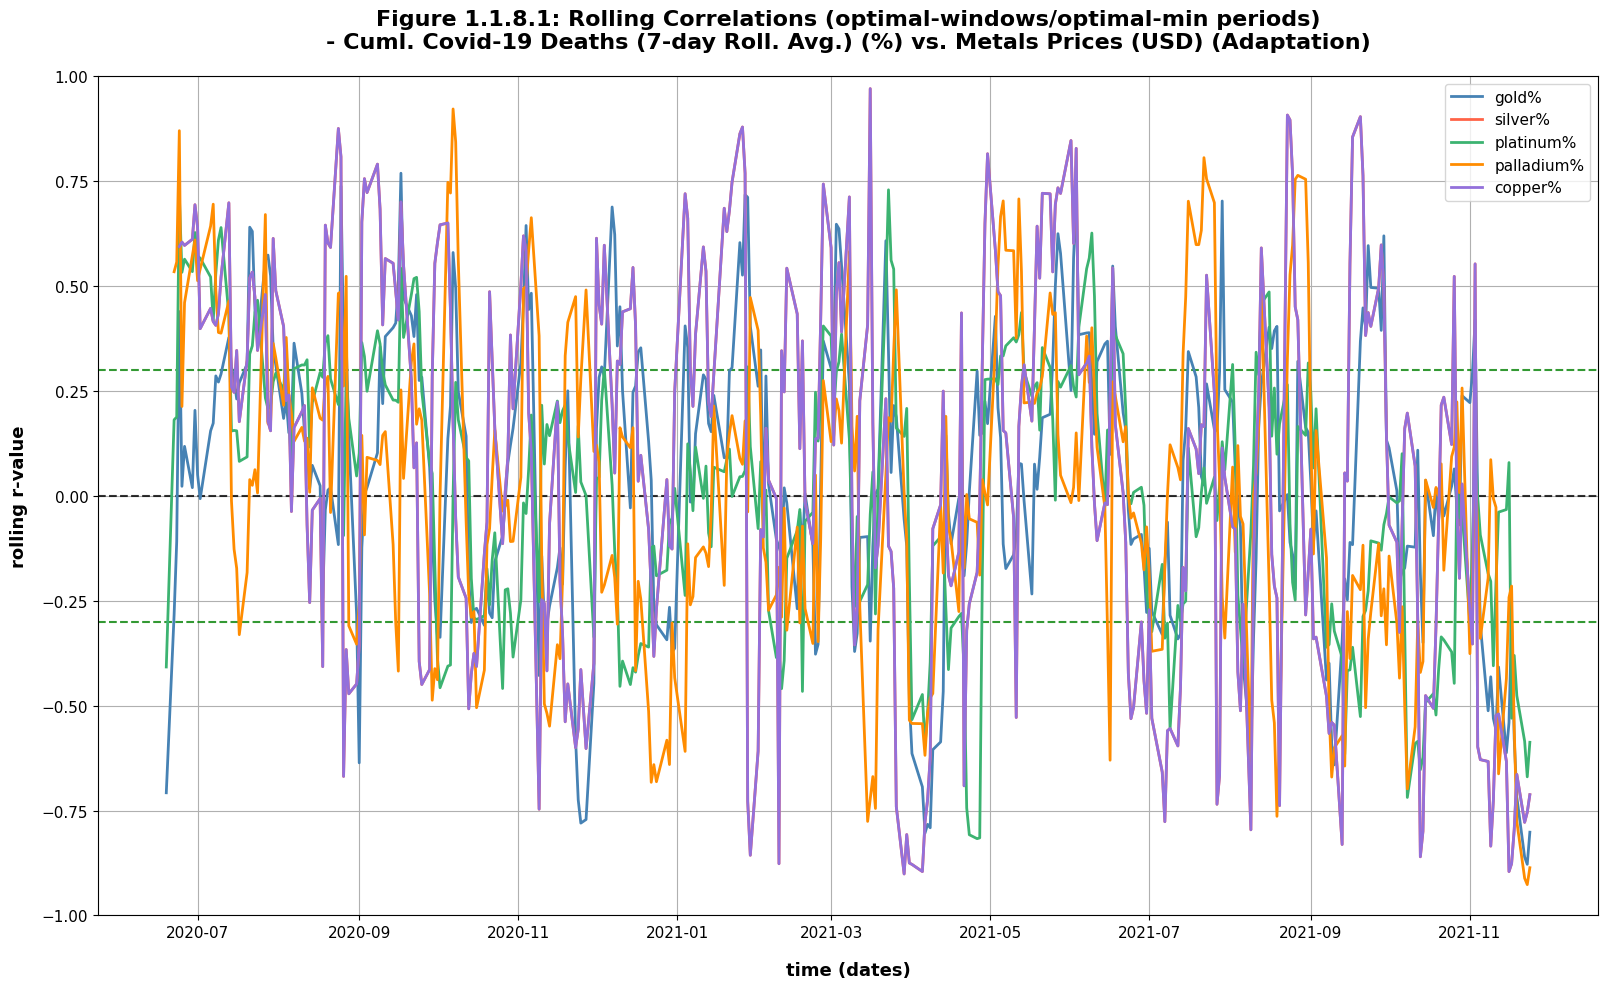

In [121]:
title = 'Figure 1.1.8.1: Rolling Correlations (optimal-windows/optimal-min periods)\n' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

matplotlibx.set_roll_corr_all_xylabels('time (dates)', 'rolling r-value')

matplotlibx.plot_all_rolling_corrs_lines(x_series, comp_dict, title, roll_corr_df)

### **Lag Correlation Summary: X vs. Y**

In [122]:
title = 'Table 1.1.8.8: Lag Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.lag_corr_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['r_same_day', 'r_peak', 'r_improvement']) \
    .format('{:,.6f}', subset = ['p_same_day', 'raw_p_peak', 'p_peak_bonferroni'])

,r_same_day,p_same_day,significant,peak_lag,r_peak,raw_p_peak,p_peak_bonferroni,significant_peak,r_improvement
series,,,,,,,,,
palladium%,0.031,0.559440,False,45,0.142,0.010772,1.000000,False,0.112
gold%,0.054,0.304788,False,-103,0.147,0.017295,1.000000,False,0.093
platinum%,0.106,0.043622,True,10,0.118,0.026807,1.000000,False,0.012
silver%,0.124,0.017508,True,5,0.124,0.018272,1.000000,False,0.000
copper%,0.124,0.017508,True,5,0.124,0.018272,1.000000,False,0.000


### **Lag Correlation Heatmap: X vs. Y**

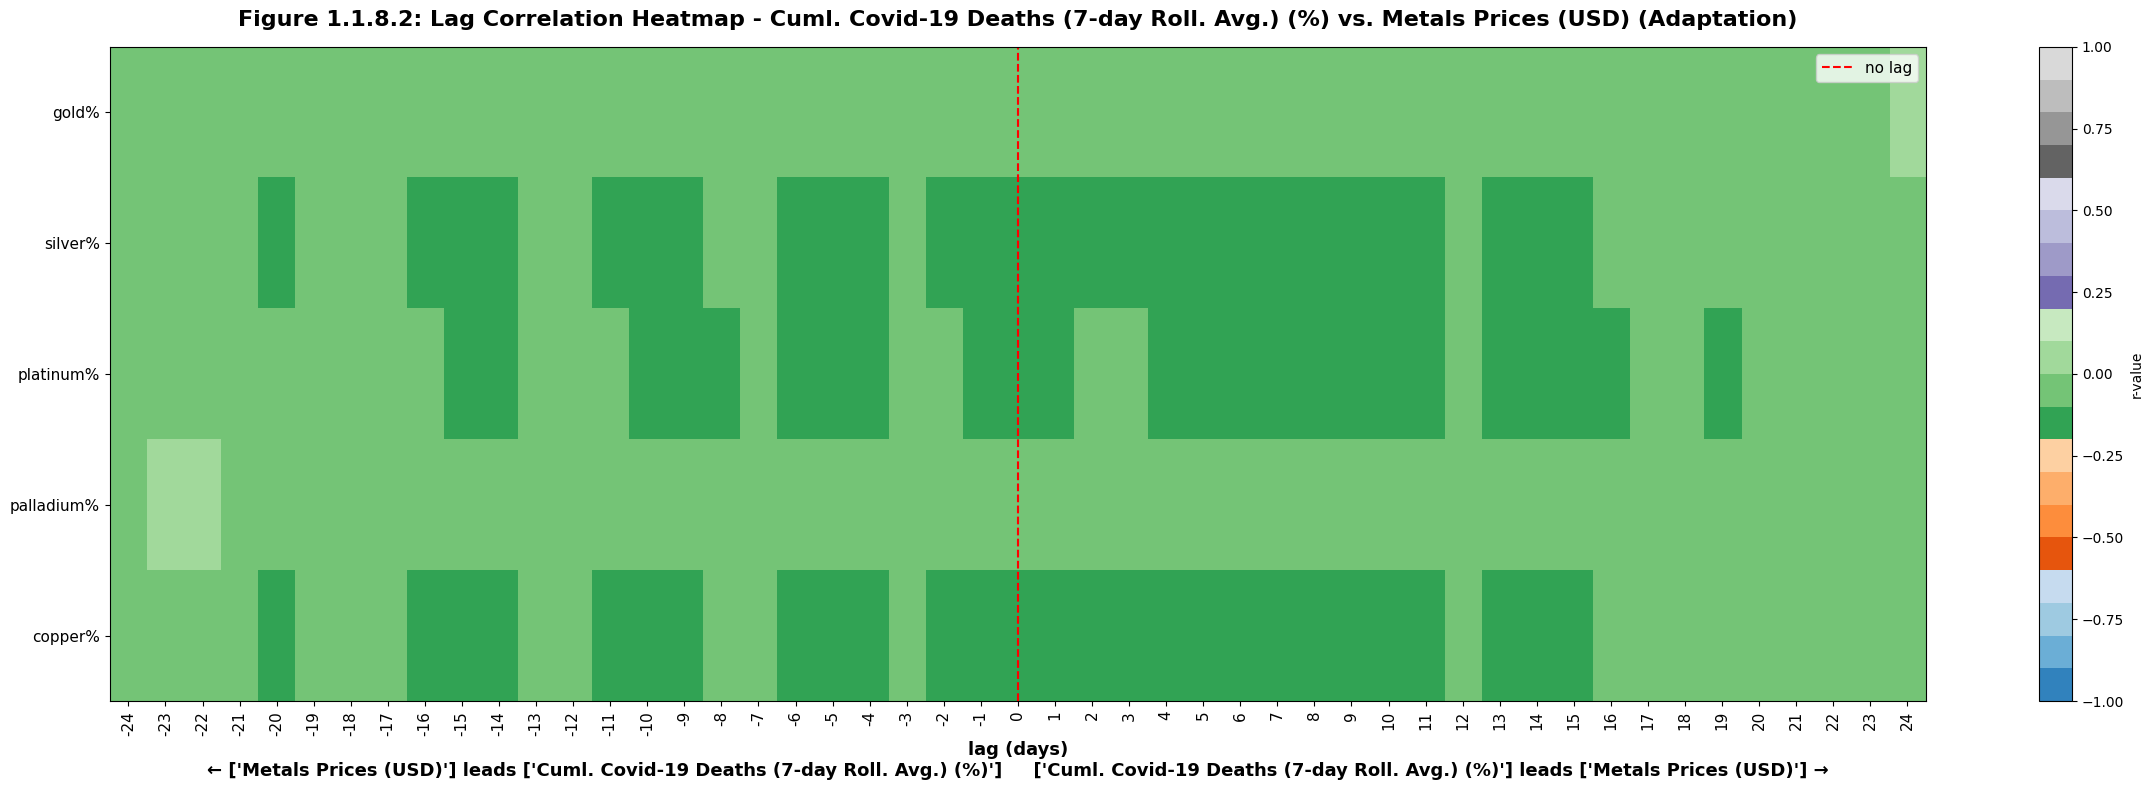

In [123]:
title = 'Figure 1.1.8.2: Lag Correlation Heatmap ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


matplotlibx.set_lag_heat_xylabels(XTTL, YSBJ)

matplotlibx.set_lag_heat_corr_method(corr_method)


matplotlibx.plot_lag_heatmap(x_series, comp_dict, title, max_lag = max_max_lag)

---

## Interpretation: Section 1.1.8 — Summary Results Across All Five Metal Price Series

**Cross-Metal Correlation Matrix (Table 1.1.8.1).** The full correlation matrix presents pairwise correlations between the `covid_deaths` pct-change X series and all five metal return Y series, as well as the Y–Y cross-correlations among the metals themselves. In percentage-change form, high Y–Y correlations among the metals indicate that the five series share substantial common return variance — likely reflecting the broad commodity supercycle dynamics of 2020–2021 rather than COVID-specific factors. High Y–Y correlations reduce the analytical independence of the five metals as separate Y series; if four of the five have pairwise correlations above 0.7, the analysis is effectively testing the COVID → metals channel once rather than five times. The X–Y correlation column reveals which metal's returns were most tightly linked to COVID death-rate changes on a contemporaneous basis.

**Polynomial Degrees Summary (Table 1.1.8.2).** The cross-metal comparison of optimal polynomial degrees, training R², and cross-validated R² provides a fit quality and stability assessment for each death-rate → metal return relationship. A consistently low CV R² across all five metals (below 0.05) would indicate that COVID death-rate percentage changes explain very little of the variation in metal returns in this period — consistent with the expected attenuation of the COVID signal during Adaptation. A low CV R² is not necessarily inconsistent with a significant Granger test: Granger tests can reject the null even when the added predictive power is small, if the sample size is large enough (536 days provides substantial power). The `cv_r2_std` column identifies which relationships are most stable across cross-validation folds, distinguishing robust signals from noise.

**Engle-Granger Cointegration (Table 1.1.8.3).** Applied to percentage-change series, the Engle-Granger cointegration test will almost certainly find no cointegration, since cointegration requires both series to be I(1) — a requirement not satisfied by percentage changes of I(1) levels. The table is included for completeness and as a diagnostic: failure to find cointegration for all five pairs is the expected result and confirms that the VAR (rather than VECM) framework is appropriate for the percentage-change data. Any unexpected rejection of the no-cointegration null for a specific metal would merit investigation, likely reflecting a measurement or data quality issue rather than a genuine long-run equilibrium relationship between death-rate changes and metal return changes.

**Granger Causality Summary (Table 1.1.8.4).** This is the pivotal table for assessing the central hypothesis. The ten direction-pairs (five metals × two directions) are presented together, enabling a direct count of how many X→Y pairs are significant and whether the Y→X direction is systematically significant or not. The key interpretive benchmark: if X→Y is significant for three or more metals at a 5% significance level, the Adaptation period data supports a broad COVID death-rate → metals return predictability finding. If significant for fewer than three, the finding is metal-specific. Significant Y→X results across multiple metals would indicate bidirectionality — metals anticipating COVID death trends — and would require a cautious interpretation given the implausibility of commodity prices genuinely predicting future mortality.

**VAR/VECM Analysis Summary (Table 1.1.8.5).** The FEVD X-share column provides a magnitude-of-effect complement to the binary Granger significance results. Even if multiple X→Y Granger tests are significant, the FEVD quantifies what fraction of each metal's return variance is attributable to COVID death-rate shocks. During the Adaptation period, FEVD X-shares for metals are expected to be lower than the X-shares found for stock market indices during the Initial Shock — reflecting the weaker causal role of COVID data in a more normalized pandemic environment. X-shares in the 5–20% range would represent meaningful but not dominant COVID influence; X-shares below 5% would suggest that while COVID deaths Granger-cause metal returns, the practical explanatory contribution is small relative to the commodity cycle's own dynamics.

**Rolling Correlation Analysis (Tables 1.1.8.6–1.1.8.7 and Figure 1.1.8.1).** The consolidated rolling correlation chart (Figure 1.1.8.1) places all five metal rolling correlations on a common time axis, making it possible to identify whether the COVID death-rate/metals relationship strengthened or weakened at identifiable macro events: the initial vaccine announcements (November 2020), the rollout acceleration (spring 2021), and the Delta wave onset (summer 2021). A temporary strengthening of rolling correlations during the Delta wave, visible across multiple metals simultaneously, would confirm that wave resurgences episodically reactivated the pandemic → commodity channel even during the Adaptation period. The stability metric in Table 1.1.8.6 (`rc_std`) quantifies how much each metal's rolling correlation varied over the window: high `rc_std` indicates an episodic relationship, while low `rc_std` indicates consistent but possibly weak association throughout.

**Lag Correlation Summary and Heatmap (Table 1.1.8.8 and Figure 1.1.8.2).** The lag correlation summary identifies the peak lag and Bonferroni-corrected peak lag p-value for each of the five metals. The `r_improvement` column — the difference between peak lag correlation and same-day correlation — is especially informative in this percentage-change context: a positive improvement means that COVID death-rate changes are more strongly associated with metal returns at some future date than on the same day, confirming that the causal direction runs forward in time (COVID data leads metal prices). The lag heatmap consolidates this across all five metals: a consistent hot spot at a positive lag of 5–14 days across multiple metals would be strong evidence of a systematic, delayed transmission of pandemic severity information into metal commodity prices during the Adaptation period — and would identify the optimal lag structure for any downstream predictive model that uses `covid_deaths` changes as a commodity market signal.

---

### Overall Conclusion

The Adaptation period presents the most analytically complex environment of the three phases studied. Unlike the Initial Shock — where COVID dominated market dynamics and the causal direction was unambiguous — the Adaptation period involves a pandemic signal competing with powerful non-COVID drivers (monetary policy normalization expectations, global supply chain disruption, infrastructure spending, and the commodity supercycle). The question this notebook addresses is whether the COVID death-rate percentage-change series retained statistically detectable and directionally interpretable predictive power over metal returns under these conditions.

A finding of Granger causality (X→Y) for a majority of metals, combined with FEVD X-shares of 5–20% and a consistent positive peak lag of 5–14 days, would constitute a robust — if attenuated — COVID → metals channel during Adaptation: mortality data was still being processed by commodity markets with a multi-day delay, contributing meaningfully to price variance even as the pandemic's dominance as a market driver waned. A finding of weak or absent Granger causality for most metals would confirm that the metals complex had largely decoupled from pandemic severity signals by mid-2020, with any remaining association attributable to shared macro exposure rather than direct COVID → commodity transmission.

Either outcome contributes to the broader project's understanding of how COVID's causal influence on asset classes evolved across pandemic phases — and why the Adaptation period's optimal candidate pairing of `covid_deaths` → `metals` in percentage changes, with a composite score of 56.60, sits above the Full Period score but below the Initial Shock's peak of 66.06.

---


In [124]:
logx.end_program()

Program execution begins at 2026/05/03 16:20:36.
Program execution ends at 2026/05/03 16:25:48.

Program execution ran for 00:05:12.

